# Grupo 7 - Política Pública y Asignación de Recursos

CC2017 Modelación y Simulación - Examen Práctico, Semana 10 - Escenario de terremoto M6.8 en Ciudad UVG, 5 zonas, horizonte de 72 horas (12 bloques de 6h).

Rol del grupo: el Grupo 7 no entrega a otro grupo, produce el output de cierre del examen (plan de asignación de recursos, justificación cuantitativa, evaluación contra las cuatro métricas de política y análisis de sensibilidad), usando la información propia del archivo Excel y la que se reciba en el intercambio presencial de los Grupos 2, 3 y 5.

Este notebook es el entregable único y autocontenido del Grupo 7: construye el modelo, ejecuta la simulación de Monte Carlo, evalúa las cuatro métricas de política, integra los reportes del intercambio presencial y produce la salida final requerida por el examen. No existe un paquete `src/` separado: cada función, dataclass y constante usada abajo está definida directamente en este notebook, en el orden de las secciones que exige el reporte final (ver `docs/reporte_estructura.md`).

Este notebook separa dos tipos de contenido:

- Código funcional: ya implementado y probado, carga los datos reales del   archivo `docs/Grupo7_PoliticaPublica.xlsx` y corre la simulación.
- Secciones de redacción que el equipo todavía debe escribir con su propio   razonamiento: están marcadas explícitamente `[PENDIENTE - equipo]` y   deliberadamente en blanco (o con una nota de referencia claramente   etiquetada como tal) para que no se confundan con trabajo ya terminado.

Si el equipo usa IA generativa para redactar esas secciones, debe documentar el prompt utilizado y por qué funcionó en `docs/prompts_ia.md` (requisito explícito del examen, ver Sección 11).

Índice de secciones de este notebook:

0. Portada y contexto
1. Justificación del paradigma
2. Descripción del modelo (ODD simplificado)
3. Datos de entrada (carga y verificación del Excel)
4. Motor de simulación (parámetros, políticas, restricciones, modelo SD, métricas, Monte Carlo)
5. Resultados: Pregunta 1 (análisis propio, antes del intercambio)
6. Intercambio presencial: información recibida de los Grupos 2, 3 y 5
7. Resultados: Pregunta 2 (integración del intercambio)
8. Análisis de sensibilidad (salida requerida d)
9. Salida final requerida (a, b, c, d) y exportación
10. Limitaciones y propuestas de mejora
11. Documentación de uso de IA generativa


In [1]:
import re
import sys
from dataclasses import dataclass, field, replace
from pathlib import Path

import numpy as np
import openpyxl
import pandas as pd
import matplotlib.pyplot as plt

# Este notebook vive en <project_root>/notebooks/Grupo7_Modelo.ipynb.
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

print(f"Raiz del proyecto: {PROJECT_ROOT}")
print(f"Versión de Python: {sys.version}")


Raiz del proyecto: /home/jonialen/Documents/uvg/s8/mod/examenP1
Versión de Python: 3.12.13 (main, Jun 23 2026, 15:18:55) [Clang 22.1.3 ]


## 1. Justificación del paradigma

### Nota de referencia (apoyo técnico, no es la justificación final)

Paradigma de partida: Dinámica de Sistemas (stock-and-flow agregado) más una capa programada de decisión/control.

- El objeto de estudio es el pool agregado de recursos, la necesidad   insatisfecha y el backlog por zona, no personas, vehículos o tomadores de   decisiones individuales. Esto es un indicio en contra de un Modelo Basado   en Agentes: ningún agente individualmente distinguible es la unidad de   análisis aquí.
- No existe una disciplina de colas de entidades discretas (no hay proceso   explicito de llegadas, tiempos de servicio, ni cola de entidades   individualmente rastreadas), lo cual es un indicio en contra de la   Simulación de Eventos Discretos.
- Lo que el modelo sí tiene implementado es: (a) stocks que persisten y   evolucionan en el tiempo con salidas explícitas, la dotación de recursos   se agota bloque a bloque, y la necesidad insatisfecha se acumula en un   stock de backlog con arrastre (carryover) y crecimiento de urgencia (un   ciclo de retroalimentación clásico de SD); y (b) una decisión que se   reevalua en un horario fijo (cada bloque de 6 horas), no disparada por   eventos discretos, es decir, una capa de control programada sobre el   núcleo SD.

Esta nota es un punto de partida técnico basado en como quedo construido el código de la Sección 4, no una justificación de paradigma ya decidida ni argumentada con los criterios de clase. Le corresponde al equipo escribirla.

### Justificación del paradigma - `[PENDIENTE - equipo]`

Qué debe llevar esta sección (máximo 1 página en el reporte final, ver `docs/reporte_estructura.md`):

- Que paradigma (o combinación de SD / ABM / DES) usa el grupo para modelar   la asignación de recursos.
- Por qué ese paradigma es el más adecuado para la pregunta que responde el   grupo, citando explícitamente los criterios de selección vistos en clase   (representación del estado, representación del tiempo, granularidad de   las entidades).
- Si se combinan paradigmas, dónde está la frontera entre ellos y por qué esa   frontera no cruza hacia ABM o DES.

Esta sección queda deliberadamente en blanco: la nota de referencia de arriba es una pista sobre la forma del código, no una justificación ya argumentada ni un texto para copiar.


## 2. Descripción del modelo (ODD simplificado)

### Nota de referencia (apoyo técnico, no es la descripción final)

Recordatorio de la formulación stock-and-flow de Dinámica de Sistemas (usada en `simulate`, Sección 4.4): `S(t+1) = S(t) + inflow(t)*dt - outflow(t)*dt`. El modelo rastrea dos familias de stock (dt = 1 bloque = 6h):

- `remaining_stock[resource]`: la dotación fija de T0 (tomada del Excel) se   agota conforme se asigna (outflow = allocation; sin inflow, ya que el   archivo da una dotación única sin calendario de reabastecimiento).
- `backlog[zone]`: un índice adimensional de faltante relativo (no unidades   crudas, ya que los 8 recursos tienen unidades incompatibles), con   decaimiento por arrastre y crecimiento compuesto de urgencia.

### Descripción del modelo (ODD simplificado) - `[PENDIENTE - equipo]`

Describir, con las propias palabras del equipo y en base al código de la Sección 4, cada punto:

- Entidades y atributos: usar `ZONES`, `RESOURCE_TYPES`, `params.zones`,   `params.damage_index`, `params.population_at_risk` como referencia   concreta de que describir.
- Reglas de comportamiento y ecuaciones de estado: usar `simulate` y las   funciones de `POLICIES` como referencia.
- Modo de scheduling (si aplica): revisar el bucle `for t in   range(n_blocks)` de `simulate`.
- Mecanismo de comunicación entre entidades (o ausencia de el).
- Distribución inicial de atributos: revisar `Params.default()` y   `cargar_datos()` (Sección 3).

El código ya implementa todo esto: se usa como referencia concreta de que describir, no como texto a copiar.


## 3. Datos de entrada (carga y verificación del Excel)

`docs/Grupo7_PoliticaPublica.xlsx` (hoja `Datos_Grupo7`) ya llegó. A partir de esta sección, el Excel es la ÚNICA fuente de verdad de los recursos disponibles, sus costos unitarios, la tabla de zonas (daño, población en riesgo, prioridad declarada) y la definición de las cuatro métricas de evaluación (umbral y peso): `cargar_datos()` lee la hoja directamente recorriendo sus filas, sin hardcodear ningún valor.

Los valores que antes estaban codificados directamente en `Params` quedan ahora como constantes de respaldo (`HARDCODED_*`), útiles únicamente para que el notebook pueda seguir corriendo si el archivo Excel no está disponible. La función `verificar_contra_excel()` compara lo parseado del Excel contra esas constantes de respaldo y avisa (no lanza una excepción) si llegan a diferir, por ejemplo si alguien edita el archivo Excel más adelante.

`describe_workbook()` se mantiene como utilidad genérica de inspección (nombres de hoja, forma, columnas), útil si más adelante llega un archivo Excel nuevo con una estructura distinta.


In [2]:
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_EXCHANGE = PROJECT_ROOT / "data" / "exchange"
DOCS_DIR = PROJECT_ROOT / "docs"
OUTPUTS = PROJECT_ROOT / "outputs"
OUTPUTS.mkdir(exist_ok=True)

EXCEL_PATH = DOCS_DIR / "Grupo7_PoliticaPublica.xlsx"
HOJA = "Datos_Grupo7"


def describe_workbook(path=None):
    """Imprime los nombres de hoja, formas, columnas y encabezado de un libro de Excel.

    Si `path` es None, busca primero `EXCEL_PATH`, luego cualquier .xlsx en
    data/raw/. Imprime un mensaje claro en lugar de lanzar una excepción si
    no encuentra nada. Útil si más adelante llega un archivo Excel nuevo con
    una estructura distinta a la de Grupo7_PoliticaPublica.xlsx.
    """
    if path is None:
        if EXCEL_PATH.exists():
            path = EXCEL_PATH
        else:
            candidates = sorted(DATA_RAW.glob("*.xlsx"))
            if not candidates:
                print(f"No se encontro ningún archivo .xlsx en {EXCEL_PATH} ni en {DATA_RAW}.")
                print("Coloque el archivo Excel del Grupo 7 alli y vuelva a ejecutar esta celda.")
                return None
            path = candidates[0]
    path = Path(path)
    sheets = pd.read_excel(path, sheet_name=None, header=None, engine="openpyxl")
    print(f"Libro: {path}")
    print(f"Hojas encontradas: {len(sheets)}")
    for name, df in sheets.items():
        print("=" * 72)
        print(f"Hoja: {name!r}  forma={df.shape}")
        print(df.head(10))
        print()
    return sheets


_ = describe_workbook()


Libro: /home/jonialen/Documents/uvg/s8/mod/examenP1/docs/Grupo7_PoliticaPublica.xlsx
Hojas encontradas: 1
Hoja: 'Datos_Grupo7'  forma=(48, 5)
                                                   0          1  \
0  EXAMEN PRÁCTICO — SEMANA 10 | Ciudad UVG — Ter...        NaN   
1  GRUPO 7: Política Pública y Asignación de Recu...        NaN   
2  Fuente: datos sintéticos calibrados con paráme...        NaN   
3                                                NaN        NaN   
4  1. RECURSOS DISPONIBLES PARA ASIGNACIÓN (presu...        NaN   
5                                            Recurso     Unidad   
6                   Presupuesto emergencia municipal  Quetzales   
7                    Presupuesto emergencia nacional  Quetzales   
8               Vehículos pesados (retroexcavadoras)   unidades   
9                          Vehículos de distribución   unidades   

               2                   3                                4  
0            NaN                 NaN            

In [3]:
# Mapea el nombre en espanol de cada recurso, tal como aparece en el Excel,
# a la clave interna usada en todo el notebook (RESOURCE_TYPES, Sección 4).
NOMBRES_RECURSOS = {
    "Presupuesto emergencia municipal": "presupuesto_municipal",
    "Presupuesto emergencia nacional": "presupuesto_nacional",
    "Vehículos pesados (retroexcavadoras)": "vehiculos_pesados",
    "Vehículos de distribución": "vehiculos_distribucion",
    "Generadores de emergencia": "generadores",
    "Combustible": "combustible",
    "Kits de agua potable (purificación)": "kits_agua",
    # NOTA de fusión: el notebook de referencia de la compañera usaba la
    # clave interna "tiendas"; se homologa aquí a "tiendas_campana" para
    # respetar la clave que ya usa el resto del notebook (RESOURCE_TYPES,
    # Params, simulate) y no tener dos nombres internos para el mismo recurso.
    "Tiendas de campaña (albergue temporal)": "tiendas_campana",
}

# Homologa el texto de prioridad tal como aparece en el Excel (con tilde,
# prosa en espanol) al código interno usado en todo el notebook (sin tilde,
# igual que los codigos Z1..Z5 y C1..C5).
PRIORIDAD_EXCEL_A_CODIGO = {
    "CRÍTICA": "CRITICA", "CRITICA": "CRITICA",
    "ALTA": "ALTA", "MODERADA": "MODERADA", "BAJA": "BAJA",
}


def _extraer_numero(texto):
    """Extrae el primer número (entero o decimal) de un texto libre, por ejemplo '< 15%' -> 15.0."""
    match = re.search(r"[-+]?\d*\.?\d+", str(texto))
    if match is None:
        raise ValueError(f"No se encontro un número en el texto: {texto!r}")
    return float(match.group())


def cargar_datos(path=EXCEL_PATH, hoja=HOJA):
    """Lee Datos_Grupo7 directamente del Excel: recursos, zonas, restricciones y métricas.

    Esta es la única fuente de verdad de recursos, costos unitarios, tabla
    de zonas y definición de las cuatro métricas. No hardcodea ningún valor:
    si el Excel cambia, este notebook cambia con el.
    """
    wb = openpyxl.load_workbook(path, data_only=True)
    ws = wb[hoja]

    recursos_inicial, costo_unitario = {}, {}
    for row in ws.iter_rows(min_row=7, max_row=14, values_only=True):
        nombre, unidad, disponible, costo, fuente = row[:5]
        key = NOMBRES_RECURSOS[nombre]
        recursos_inicial[key] = disponible
        costo_unitario[key] = costo

    zonas_rows = []
    for row in ws.iter_rows(min_row=18, max_row=22, values_only=True):
        zona_txt, danio, pob, prioridad, justif = row[:5]
        zonas_rows.append({
            "zona": zona_txt.split(" ")[0],
            "nombre": zona_txt,
            "danio": float(danio),
            "pob_riesgo": int(pob),
            "prioridad": PRIORIDAD_EXCEL_A_CODIGO.get(prioridad, prioridad),
            "justificacion": justif,
        })
    zonas = pd.DataFrame(zonas_rows).set_index("zona")

    restricciones = {}
    for row in ws.iter_rows(min_row=25, max_row=29, values_only=True):
        clave, texto = row[0], row[1]
        restricciones[clave.rstrip(":")] = texto

    metricas_rows = []
    for row in ws.iter_rows(min_row=33, max_row=36, values_only=True):
        nombre, definicion, umbral, peso = row[:4]
        metricas_rows.append({
            "metrica": nombre, "definicion": definicion,
            "umbral": umbral, "umbral_valor": _extraer_numero(umbral),
            "peso": peso, "peso_valor": _extraer_numero(peso) / 100.0,
        })
    metricas_def = pd.DataFrame(metricas_rows).set_index("metrica")

    return recursos_inicial, costo_unitario, zonas, restricciones, metricas_def


def _cargar_datos_o_ninguno():
    if not EXCEL_PATH.exists():
        print(f"{EXCEL_PATH} no encontrado: se usan las constantes de respaldo codificadas (HARDCODED_*).")
        return None
    return cargar_datos()


_datos_excel = _cargar_datos_o_ninguno()
if _datos_excel is not None:
    recursos_inicial, costo_unitario, zonas, restricciones, metricas_def = _datos_excel
else:
    recursos_inicial, costo_unitario, zonas, restricciones, metricas_def = None, None, None, None, None

if zonas is not None:
    print("Tabla de zonas (parseada desde el Excel):")
    display(zonas)
    print("Definición de métricas (parseada desde el Excel):")
    display(metricas_def)


Tabla de zonas (parseada desde el Excel):


,nombre,danio,pob_riesgo,prioridad,justificacion
zona,,,,,
Z1,Z1 (Centro histórico),8.4,28400,CRITICA,Mayor densidad + mayor daño estructural
Z2,Z2 (Norte residencial),3.1,6800,MODERADA,"Daño limitado, buena accesibilidad"
Z3,Z3 (Sur industrial),5.8,14200,ALTA,Zona industrial — riesgo de contaminación
Z4,Z4 (Este comercial),2.2,4100,BAJA,"Menor daño, mejor infraestructura"
Z5,Z5 (Oeste periférico),9.1,31400,CRITICA,Mayor daño + mayor vulnerabilidad + peor acceso


Definición de métricas (parseada desde el Excel):


,definicion,umbral,umbral_valor,peso,peso_valor
metrica,,,,,
Tasa de mortalidad evitable,% fallecidos que pudieron salvarse con respues...,< 15%,15.0,30%,0.30
Tiempo promedio de respuesta,Horas desde el evento hasta primera intervenci...,< 6h en zonas críticas,6.0,25%,0.25
Cobertura de suministros,% de desplazados con acceso a agua y alimento ...,> 80%,80.0,25%,0.25
Eficiencia presupuestaria,Personas atendidas por millón de Q gastado,> 850 personas/MQ,850.0,20%,0.20


In [4]:
# --- Constantes de respaldo (HARDCODED_*) --------------------------------
# Transcripción directa de docs/Grupo7_PoliticaPublica.xlsx al momento de
# construir este notebook. Solo se usan si el Excel no esta disponible, o
# como base de comparación de verificar_contra_excel() de abajo.
HARDCODED_DAMAGE_INDEX = {"Z1": 8.4, "Z2": 3.1, "Z3": 5.8, "Z4": 2.2, "Z5": 9.1}
HARDCODED_POPULATION_AT_RISK = {"Z1": 28_400, "Z2": 6_800, "Z3": 14_200, "Z4": 4_100, "Z5": 31_400}
HARDCODED_DECLARED_PRIORITY = {
    "Z1": "CRITICA", "Z2": "MODERADA", "Z3": "ALTA", "Z4": "BAJA", "Z5": "CRITICA",
}
HARDCODED_JUSTIFICATION = {
    "Z1": "Mayor densidad + mayor daño estructural",
    "Z2": "Daño limitado, buena accesibilidad",
    "Z3": "Zona industrial - riesgo de contaminación",
    "Z4": "Menor daño, mejor infraestructura",
    "Z5": "Mayor daño + mayor vulnerabilidad + peor acceso",
}
HARDCODED_ZONE_NAME = {
    "Z1": "Centro histórico", "Z2": "Norte residencial", "Z3": "Sur industrial",
    "Z4": "Este comercial", "Z5": "Oeste periferico",
}
HARDCODED_RESOURCE_AVAILABLE_T0 = {
    "presupuesto_municipal": 8_500_000.0, "presupuesto_nacional": 32_000_000.0,
    "vehiculos_pesados": 12.0, "vehiculos_distribucion": 57.0,
    "generadores": 18.0, "combustible": 8_400.0,
    "kits_agua": 2_800.0, "tiendas_campana": 420.0,
}
HARDCODED_UNIT_COST = {
    "presupuesto_municipal": 1.0, "presupuesto_nacional": 1.0,
    "vehiculos_pesados": 18_000.0, "vehiculos_distribucion": 2_500.0,
    "generadores": 8_500.0, "combustible": 28.0,
    "kits_agua": 120.0, "tiendas_campana": 850.0,
}
HARDCODED_RESOURCE_UNIT = {
    "presupuesto_municipal": "quetzales", "presupuesto_nacional": "quetzales",
    "vehiculos_pesados": "unidades", "vehiculos_distribucion": "unidades",
    "generadores": "unidades", "combustible": "galones",
    "kits_agua": "kits", "tiendas_campana": "unidades",
}
HARDCODED_FUNDING_SOURCE = {
    "presupuesto_municipal": "Fondo municipal contingencias",
    "presupuesto_nacional": "SE-CONRED / Presidencia",
    "vehiculos_pesados": "Municipalidad + empresa privada",
    "vehiculos_distribucion": "Flota municipal + ONG",
    "generadores": "Reserva estrategica CONRED",
    "combustible": "Reserva estrategica",
    "kits_agua": "SESAN / UNICEF",
    "tiendas_campana": "Cruz Roja / CONRED",
}
# Umbral y peso de las 4 métricas, transcritos de la sección "4. MÉTRICAS DE
# EVALUACIÓN DE LA POLÍTICA" del Excel (ver también METRIC_DEFS, Sección 4.6).
HARDCODED_METRIC_THRESHOLD = {
    "M1_tasa_mortalidad_evitable": 15.0, "M2_tiempo_promedio_respuesta": 6.0,
    "M3_cobertura_suministros": 80.0, "M4_eficiencia_presupuestaria": 850.0,
}
HARDCODED_METRIC_WEIGHT = {
    "M1_tasa_mortalidad_evitable": 0.30, "M2_tiempo_promedio_respuesta": 0.25,
    "M3_cobertura_suministros": 0.25, "M4_eficiencia_presupuestaria": 0.20,
}

METRICA_EXCEL_A_CLAVE = {
    "Tasa de mortalidad evitable": "M1_tasa_mortalidad_evitable",
    "Tiempo promedio de respuesta": "M2_tiempo_promedio_respuesta",
    "Cobertura de suministros": "M3_cobertura_suministros",
    "Eficiencia presupuestaria": "M4_eficiencia_presupuestaria",
}


def verificar_contra_excel(zonas, recursos_inicial, costo_unitario, metricas_def):
    """Compara los valores parseados del Excel contra las constantes de
    respaldo HARDCODED_*, e imprime PASS/WARN por cada verificación en lugar
    de lanzar una excepción. Útil para detectar de inmediato si el archivo
    Excel cambió respecto a cuando se transcribieron las constantes de
    respaldo (por ejemplo si alguien lo edita más adelante).
    """
    if zonas is None:
        print("Se omite la verificación: el Excel no fue parseado (no esta disponible).")
        return

    checks = []
    checks.append(("5 zonas parseadas", len(zonas) == 5))
    checks.append(("8 recursos parseados", len(recursos_inicial) == 8))
    checks.append(("4 métricas parseadas", len(metricas_def) == 4))

    for z in HARDCODED_DAMAGE_INDEX:
        if z not in zonas.index:
            checks.append((f"zona {z} presente en el Excel", False))
            continue
        checks.append((f"índice de daño de {z} == {HARDCODED_DAMAGE_INDEX[z]}",
                        float(zonas.loc[z, "danio"]) == HARDCODED_DAMAGE_INDEX[z]))
        checks.append((f"población en riesgo de {z} == {HARDCODED_POPULATION_AT_RISK[z]}",
                        int(zonas.loc[z, "pob_riesgo"]) == HARDCODED_POPULATION_AT_RISK[z]))
        checks.append((f"prioridad declarada de {z} == {HARDCODED_DECLARED_PRIORITY[z]}",
                        zonas.loc[z, "prioridad"] == HARDCODED_DECLARED_PRIORITY[z]))

    for r, hardcoded_valor in HARDCODED_RESOURCE_AVAILABLE_T0.items():
        checks.append((f"disponible T0 de {r} == {hardcoded_valor}",
                        r in recursos_inicial and float(recursos_inicial[r]) == hardcoded_valor))
        checks.append((f"costo unitario de {r} == {HARDCODED_UNIT_COST[r]}",
                        r in costo_unitario and float(costo_unitario[r]) == HARDCODED_UNIT_COST[r]))

    for nombre_excel, clave in METRICA_EXCEL_A_CLAVE.items():
        if nombre_excel not in metricas_def.index:
            checks.append((f"métrica '{nombre_excel}' presente en el Excel", False))
            continue
        fila = metricas_def.loc[nombre_excel]
        checks.append((f"umbral de {clave} == {HARDCODED_METRIC_THRESHOLD[clave]}",
                        fila["umbral_valor"] == HARDCODED_METRIC_THRESHOLD[clave]))
        checks.append((f"peso de {clave} == {HARDCODED_METRIC_WEIGHT[clave]}",
                        abs(fila["peso_valor"] - HARDCODED_METRIC_WEIGHT[clave]) < 1e-9))

    for label, ok in checks:
        print(f"[{'PASS' if ok else 'WARN'}] {label}")


verificar_contra_excel(zonas, recursos_inicial, costo_unitario, metricas_def)


[PASS] 5 zonas parseadas
[PASS] 8 recursos parseados
[PASS] 4 métricas parseadas
[PASS] índice de daño de Z1 == 8.4
[PASS] población en riesgo de Z1 == 28400
[PASS] prioridad declarada de Z1 == CRITICA
[PASS] índice de daño de Z2 == 3.1
[PASS] población en riesgo de Z2 == 6800
[PASS] prioridad declarada de Z2 == MODERADA
[PASS] índice de daño de Z3 == 5.8
[PASS] población en riesgo de Z3 == 14200
[PASS] prioridad declarada de Z3 == ALTA
[PASS] índice de daño de Z4 == 2.2
[PASS] población en riesgo de Z4 == 4100
[PASS] prioridad declarada de Z4 == BAJA
[PASS] índice de daño de Z5 == 9.1
[PASS] población en riesgo de Z5 == 31400
[PASS] prioridad declarada de Z5 == CRITICA
[PASS] disponible T0 de presupuesto_municipal == 8500000.0
[PASS] costo unitario de presupuesto_municipal == 1.0
[PASS] disponible T0 de presupuesto_nacional == 32000000.0
[PASS] costo unitario de presupuesto_nacional == 1.0
[PASS] disponible T0 de vehiculos_pesados == 12.0
[PASS] costo unitario de vehiculos_pesados == 

## 4. Motor de simulación

Esta sección agrupa todo el motor del modelo: la estructura de escenario y los parámetros (`Params`), las políticas de asignación, la infraestructura de integración del intercambio, el modelo de Dinámica de Sistemas (`simulate`), las restricciones de política C1-C5 con su registro de auditoría, las cuatro métricas de evaluación, y la simulación de Monte Carlo. Es código funcional, ya implementado y probado: las secciones siguientes (5, 7, 8, 9) lo usan para responder las preguntas del examen.

### 4.1 Constantes de escenario y parámetros del modelo (`Params`)


In [5]:
ZONES = ["Z1", "Z2", "Z3", "Z4", "Z5"]
N_ZONES = len(ZONES)

N_BLOCKS = 12
HOURS_PER_BLOCK = 6
HORIZON_HOURS = 72
assert N_BLOCKS * HOURS_PER_BLOCK == HORIZON_HOURS

# Fuente: docs/Grupo7_PoliticaPublica.xlsx, sección "1. RECURSOS DISPONIBLES
# PARA ASIGNACIÓN". Estos son los 8 rubros de recursos propios del grupo: no
# inventar categorías genericas aquí.
RESOURCE_TYPES = [
    "presupuesto_municipal",
    "presupuesto_nacional",
    "vehiculos_pesados",
    "vehiculos_distribucion",
    "generadores",
    "combustible",
    "kits_agua",
    "tiendas_campana",
]
N_RESOURCES = len(RESOURCE_TYPES)
BUDGET_RESOURCES = ["presupuesto_municipal", "presupuesto_nacional"]
PHYSICAL_RESOURCES = [r for r in RESOURCE_TYPES if r not in BUDGET_RESOURCES]

DEFAULT_SEED = 42
# El enunciado exige >= 30 replicas; 300 da intervalos de confianza del 95%
# notablemente más estrechos sin dejar de ejecutarse rápido.
N_REPLICATIONS = 300
ASSIGNMENT_MIN_REPLICATIONS = 30
CI_LEVEL = 0.95


def block_to_hours(block: int) -> tuple[int, int]:
    """Retorna la ventana (hora_inicio, hora_fin) cubierta por un bloque indexado desde 1."""
    if not (1 <= block <= N_BLOCKS):
        raise ValueError(f"block debe estar en [1, {N_BLOCKS}], se recibio {block}")
    return (block - 1) * HOURS_PER_BLOCK, block * HOURS_PER_BLOCK


# Atajo para las primeras 24 horas: bloques 1-4 (usado en la Pregunta 1).
FIRST_24H_BLOCKS = [b for b in range(1, N_BLOCKS + 1) if block_to_hours(b)[1] <= 24]
print("Tipos de recurso:", RESOURCE_TYPES)
print("Bloques de las primeras 24h:", FIRST_24H_BLOCKS)


Tipos de recurso: ['presupuesto_municipal', 'presupuesto_nacional', 'vehiculos_pesados', 'vehiculos_distribucion', 'generadores', 'combustible', 'kits_agua', 'tiendas_campana']
Bloques de las primeras 24h: [1, 2, 3, 4]


Todos los valores de `Params` a continuación provienen del Excel cargado en la Sección 3 (con las constantes `HARDCODED_*` como respaldo si el archivo no está disponible), excepto donde se marca explícitamente con `# ASSUMPTION:`: el archivo Excel da los stocks de recursos, el daño por zona, las restricciones de política y las definiciones de métricas, pero NO da tasas de necesidad per capita ni un submodelo de mortalidad. El enunciado permite explícitamente supuestos adicionales documentados cuando el archivo fuente está incompleto ("Los datos de su archivo Excel son el punto de partida... puede hacer supuestos adicionales siempre que los documente explícitamente").


In [6]:
PRIORITY_WEIGHT = {"CRITICA": 1.0, "ALTA": 0.75, "MODERADA": 0.5, "BAJA": 0.25}


@dataclass
class MortalityAssumptions:
    """Supuestos documentados para el submodelo de mortalidad evitable (métrica M1).

    El archivo Excel no provee un modelo de mortalidad. Cada constante abajo
    es un supuesto (ASSUMPTION) que el equipo debe revisar y justificar (o
    reemplazar) en el reporte final.
    """

    # ASSUMPTION: fracción base de la población en riesgo de una zona que se
    # convierte en una muerte evitable por bloque de 6h, con cobertura cero y
    # backlog cero.
    base_preventable_rate: float = 0.006

    # ASSUMPTION: multiplicador extra por unidad del índice de backlog
    # (adimensional), que representa el crecimiento compuesto de la urgencia
    # mientras más tiempo la necesidad queda insatisfecha.
    backlog_time_penalty_factor: float = 0.5

    def damage_factor(self, damage_index_0_10: float) -> float:
        """ASSUMPTION: escalamiento lineal del índice de daño (0-10) a (0-1)."""
        return damage_index_0_10 / 10.0

    def time_penalty(self, backlog_index: float) -> float:
        """ASSUMPTION: crecimiento lineal de la urgencia con el índice de backlog adimensional."""
        return 1.0 + self.backlog_time_penalty_factor * backlog_index


def _zonas_columna_o_respaldo(columna, respaldo, cast=lambda x: x):
    """Lee una columna de la tabla `zonas` cargada del Excel (Sección 3); si el
    Excel no esta disponible, usa el diccionario HARDCODED_* de respaldo.
    """
    if zonas is None:
        return dict(respaldo)
    return {z: cast(zonas.loc[z, columna]) for z in ZONES}


def _nombre_zona_o_respaldo():
    if zonas is None:
        return dict(HARDCODED_ZONE_NAME)
    nombres = {}
    for z in ZONES:
        texto = zonas.loc[z, "nombre"]
        if "(" in texto and texto.endswith(")"):
            nombres[z] = texto.split("(", 1)[1].rstrip(")")
        else:
            nombres[z] = HARDCODED_ZONE_NAME[z]
    return nombres


def _recurso_o_respaldo(diccionario_excel, respaldo):
    if diccionario_excel is None:
        return dict(respaldo)
    return {r: float(diccionario_excel[r]) for r in RESOURCE_TYPES}


@dataclass
class Params:
    zones: list = field(default_factory=lambda: list(ZONES))

    zone_name: dict = field(default_factory=_nombre_zona_o_respaldo)

    # Fuente: docs/Grupo7_PoliticaPublica.xlsx, sección
    # "2. NIVELES DE DAÑO POR ZONA (evaluación inicial)"
    damage_index: dict = field(
        default_factory=lambda: _zonas_columna_o_respaldo("danio", HARDCODED_DAMAGE_INDEX, float)
    )
    population_at_risk: dict = field(
        default_factory=lambda: _zonas_columna_o_respaldo("pob_riesgo", HARDCODED_POPULATION_AT_RISK, int)
    )
    declared_priority: dict = field(
        default_factory=lambda: _zonas_columna_o_respaldo("prioridad", HARDCODED_DECLARED_PRIORITY)
    )
    justification: dict = field(
        default_factory=lambda: _zonas_columna_o_respaldo("justificacion", HARDCODED_JUSTIFICATION)
    )

    # Fuente: docs/Grupo7_PoliticaPublica.xlsx, sección
    # "1. RECURSOS DISPONIBLES PARA ASIGNACIÓN"
    resource_unit: dict = field(default_factory=lambda: dict(HARDCODED_RESOURCE_UNIT))
    resource_available_t0: dict = field(
        default_factory=lambda: _recurso_o_respaldo(recursos_inicial, HARDCODED_RESOURCE_AVAILABLE_T0)
    )
    unit_cost: dict = field(
        default_factory=lambda: _recurso_o_respaldo(costo_unitario, HARDCODED_UNIT_COST)
    )
    funding_source: dict = field(default_factory=lambda: dict(HARDCODED_FUNDING_SOURCE))

    # ASSUMPTION: el archivo Excel da el stock total disponible en T0 pero no
    # tasas de necesidad per capita. Estas tasas se calibraron para que la
    # necesidad acumulada de 12 bloques sea aproximadamente 2x el stock fijo
    # de T0 por recurso, es decir, escasez severa pero no absurda (un
    # desajuste extremo llevaria la cobertura de toda política cerca de cero
    # y ocultaria cualquier diferencia entre políticas).
    baseline_need_per_capita: dict = field(
        default_factory=lambda: {
            "presupuesto_municipal": 17.0, "presupuesto_nacional": 63.0,
            "vehiculos_pesados": 0.00002, "vehiculos_distribucion": 0.00011,
            "generadores": 0.000035, "combustible": 0.0150,
            "kits_agua": 0.0055, "tiendas_campana": 0.0008,
        }
    )

    # Retroalimentación SD: arrastre de backlog / crecimiento de urgencia. ASSUMPTION (no esta en el Excel).
    backlog_carryover_factor: float = 0.7
    backlog_urgency_growth: float = 1.05

    # ASSUMPTION: pérdida de acceso derivada heuristicamente del índice de
    # daño (más daño estructural implica acceso físico más difícil). Un
    # índice de accesibilidad real es dominio del Grupo 4 y solo llega al
    # Grupo 7 a través del intercambio, ver la restricción C4 abajo.
    @property
    def access_loss_rate(self):
        return {z: min(0.9, self.damage_index[z] / 20.0) for z in self.zones}

    # C4 (restricción de coordinación): el Grupo 7 no recibe directamente el
    # mapa de accesibilidad de rutas del Grupo 4, por lo que la entrega de
    # vehículos pesados (vehiculos_pesados) esta adicionalmente condicionada
    # por una probabilidad ASSUMPTION documentada, por zona, de que las
    # rutas esten confirmadas como accesibles en ese bloque. Esta es una
    # limitación de modelado, senalada de nuevo en la Sección 10.
    route_availability_probability: dict = field(
        default_factory=lambda: {"Z1": 0.6, "Z2": 0.9, "Z3": 0.8, "Z4": 0.95, "Z5": 0.5}
    )

    need_coefficient_of_variation: float = 0.15
    delivery_failure_probability: float = 0.10

    mortality: MortalityAssumptions = field(default_factory=MortalityAssumptions)

    # -- Restricciones de política, sección "3. RESTRICCIONES DE LA POLÍTICA" ------
    min_rescue_teams_block1_critical: float = 1.0
    equity_max_share: float = 0.40
    equity_min_share_other_critical: float = 0.15
    national_debt_limit_fraction_24h: float = 0.80

    # -- Banderas de escenario para el análisis de sensibilidad (Sección 8) -------------------
    national_budget_multiplier: float = 1.0  # 0.5 -> presupuesto nacional reducido a la mitad
    inaccessible_zone: str = None            # por ejemplo, "Z1"
    inaccessible_blocks: tuple = ()          # por ejemplo, (1, 2)

    def __post_init__(self):
        if len(self.zones) != N_ZONES:
            raise ValueError(f"Expected {N_ZONES} zones, got {len(self.zones)}")

    @staticmethod
    def default():
        return Params()


def validate(params):
    """Verificaciones de cordura: 5 zonas, recursos no negativos, tasas en [0, 1]."""
    if sorted(params.zones) != sorted(ZONES):
        raise ValueError(f"Las etiquetas de zona {params.zones} no coinciden con las esperadas {ZONES}")
    for resource, stock in params.resource_available_t0.items():
        if stock < 0:
            raise ValueError(f"resource_available_t0[{resource}]={stock} es negativo")
    for zone, rate in params.access_loss_rate.items():
        if not (0.0 <= rate <= 1.0):
            raise ValueError(f"access_loss_rate[{zone}]={rate} fuera de [0, 1]")
    for zone, p in params.route_availability_probability.items():
        if not (0.0 <= p <= 1.0):
            raise ValueError(f"route_availability_probability[{zone}]={p} fuera de [0, 1]")
    if not (0.0 <= params.delivery_failure_probability <= 1.0):
        raise ValueError("delivery_failure_probability fuera de [0, 1]")
    if not (0.0 <= params.backlog_carryover_factor <= 1.0):
        raise ValueError("backlog_carryover_factor fuera de [0, 1]")
    print("Params validado correctamente.")


params = Params.default()
validate(params)
print("Población total en riesgo:", sum(params.population_at_risk.values()))


Params validado correctamente.
Población total en riesgo: 84900


### 4.2 Políticas de asignación

Esta es la capa de decisión/control: en cada bloque, una política reparte el pool de recursos disponible entre las 5 zonas. Todas las políticas comparten la misma firma: `policy(block, resources, need, backlog, params) -> allocation` (un arreglo de longitud `N_ZONES` que suma a lo sumo `resources`). Esta es una decisión programada (reevaluada una vez por bloque), no una decisión a nivel de agente tomada por un actor individual.


In [7]:
def _normalize_to_pool(weights, resources):
    """Escala pesos no negativos para que sumen exactamente `resources`."""
    total = weights.sum()
    if total <= 0:
        return np.full(N_ZONES, resources / N_ZONES)
    return weights / total * resources


def equal_share(block, resources, need, backlog, params):
    """Reparte los recursos equitativamente entre zonas, ignorando necesidad o daño.

    Justificación: una línea base igualitaria ("simplicidad administrativa"
    sobre "eficiencia de focalización"), útil solo como piso de comparación.
    """
    return np.full(N_ZONES, resources / N_ZONES)


def proportional_to_need(block, resources, need, backlog, params):
    """Reparte los recursos proporcionalmente a la necesidad bruta de cada zona en este bloque.

    Justificación: focalización clásica orientada a la demanda ("los
    recursos siguen a la necesidad"), ignorando el backlog acumulado y la
    vulnerabilidad.
    """
    return _normalize_to_pool(np.maximum(need, 0.0), resources)


def severity_weighted(block, resources, need, backlog, params):
    """Reparte los recursos según un puntaje de severidad = índice de daño x prioridad declarada.

    Justificación: prioriza las zonas con mayor daño estructural y
    clasificación más urgente (CRITICA/ALTA/MODERADA/BAJA), independientemente
    de la demanda bruta reportada; la justificación estandar de política
    pública de "focalizar por necesidad + vulnerabilidad" para priorizar las
    zonas más afectadas.
    """
    weights = np.array([
        (params.damage_index[z] / 10.0) * PRIORITY_WEIGHT[params.declared_priority[z]]
        for z in ZONES
    ])
    return _normalize_to_pool(weights, resources)


def worst_first(block, resources, need, backlog, params):
    """Da prioridad de asignación a la zona (o zonas) con mayor backlog.

    Justificación: una regla de triage de "arreglar primero el peor
    problema". Ejercita directamente el ciclo de retroalimentación SD: el
    backlog acumulado en bloques anteriores eleva la prioridad de una zona
    en el bloque actual.
    """
    return _normalize_to_pool(np.maximum(backlog, 0.0), resources)


def threshold_then_proportional(block, resources, need, backlog, params):
    """Garantiza un piso mínimo por zona, y luego distribuye el resto según la necesidad.

    Justificación: modela una restricción política de "ninguna zona en cero"
    (una garantia de servicio mínimo) combinada con focalización por
    necesidad para el resto. La fracción de piso (5%) es una decisión de
    diseño de política, no proviene del archivo Excel.
    """
    floor_fraction = 0.05
    floor_total = floor_fraction * resources
    floor_per_zone = np.full(N_ZONES, floor_total)
    remaining = max(resources - floor_per_zone.sum(), 0.0)
    return floor_per_zone + _normalize_to_pool(np.maximum(need, 0.0), remaining)


# PRIORIDAD_BONUS y score_prioridad: adoptados del notebook de referencia de
# la compañera (score de prioridad heterogéneo por zona), adaptados a la
# firma comun policy(block, resources, need, backlog, params) que ya usan
# las demas políticas de arriba.
PRIORIDAD_BONUS = {"CRITICA": 1.0, "ALTA": 0.66, "MODERADA": 0.33, "BAJA": 0.0}


def score_prioridad(block, resources, need, backlog, params):
    """Reparte los recursos según un score de prioridad heterogéneo por zona.

    score = 0.4 * danio_normalizado + 0.4 * poblacion_en_riesgo_normalizada + 0.2 * bono_prioridad

    Justificación: combina tres señales de vulnerabilidad (daño físico,
    magnitud de población expuesta, y la prioridad ya declarada en el
    Excel) en un único puntaje, en vez de usar una sola señal como
    severity_weighted.
    """
    damage = np.array([params.damage_index[z] for z in ZONES])
    pob = np.array([params.population_at_risk[z] for z in ZONES])
    bonus = np.array([PRIORIDAD_BONUS[params.declared_priority[z]] for z in ZONES])
    damage_norm = damage / damage.max()
    pob_norm = pob / pob.max()
    # ASSUMPTION: los pesos 0.4 / 0.4 / 0.2 son un supuesto de diseño puesto
    # por defecto para que el modelo corra; no provienen del Excel. El
    # equipo debe justificarlos en el reporte o ajustarlos y justificar la
    # alternativa elegida (ver nota markdown de esta sección).
    weights = 0.4 * damage_norm + 0.4 * pob_norm + 0.2 * bonus
    return _normalize_to_pool(weights, resources)


@dataclass
class ManualPlan:
    """Envuelve una tabla de asignación fija [block, zone] como un callable con forma de Policy.

    Usar esto para codificar a mano la propuesta inicial de 24 horas de la
    Pregunta 1: construir una tabla (n_blocks, N_ZONES) para un tipo de
    recurso y llamar esta política para ese recurso durante `simulate`. Los
    valores se usan directamente (sin renormalizar) a menos que superen el
    pool disponible, en cuyo caso se escalan hacia abajo.
    """

    table: np.ndarray

    def __call__(self, block, resources, need, backlog, params):
        row = self.table[block - 1]
        row_total = row.sum()
        if row_total > resources and row_total > 0:
            return row / row_total * resources
        return row


def manual_plan(table):
    """Fabrica que retorna una política ManualPlan ligada a una tabla de asignación fija."""
    return ManualPlan(table=np.asarray(table, dtype=float))


POLICIES = {
    "equal_share": equal_share,
    "proportional_to_need": proportional_to_need,
    "severity_weighted": severity_weighted,
    "worst_first": worst_first,
    "threshold_then_proportional": threshold_then_proportional,
    "score_prioridad": score_prioridad,
    # "manual_plan" se excluye aquí: construirla explícitamente mediante
    # manual_plan(table), ya que necesita un argumento de tabla.
}
print("Políticas:", list(POLICIES))


Políticas: ['equal_share', 'proportional_to_need', 'severity_weighted', 'worst_first', 'threshold_then_proportional', 'score_prioridad']


Nota de diseño sobre `score_prioridad`: los pesos 0.4 / 0.4 / 0.2 son un supuesto puesto por defecto para que el modelo corra, `# ASSUMPTION:` en el código de arriba. `[PENDIENTE - equipo]` el equipo debe documentar en el reporte por qué se usan así, o ajustarlos y justificar la alternativa elegida.


### 4.3 Integración del intercambio (Grupos 2, 3, 5)

El Grupo 7 RECIBE tres reportes en el intercambio presencial:

- Grupo 2: reporte de saturación hospitalaria + recursos críticos faltantes.
- Grupo 3: balance de suministros: déficit por zona y momento de agotamiento del stock.
- Grupo 5: plan de despliegue de personal + requerimientos de refuerzo.

Esta sección define los esquemas CSV esperados (reflejados en `data/exchange/README.md`, entregar esas plantillas a los Grupos 2, 3 y 5 en el intercambio) y los cargadores/validadores, más el único punto de integración (`Exchange.need_adjustment`) donde cada reporte modifica la necesidad/capacidad en `simulate` (Sección 4.4). Es infraestructura del motor de simulación: se usa tanto si los archivos reales ya llegaron como si todavía no (Sección 6 documenta que se recibio realmente en el intercambio presencial; Sección 7 corre la comparación antes/después).


In [8]:
G2_HOSPITAL_COLUMNS = ["zone", "block", "saturation_index", "critical_resource", "deficit_units"]
G3_SUPPLIES_COLUMNS = ["zone", "block", "supply_type", "balance_units", "bottleneck_flag"]
G5_PERSONNEL_COLUMNS = ["zone", "block", "personnel_assigned", "reinforcement_needed"]


def _validate_columns(df, expected, source):
    missing = [c for c in expected if c not in df.columns]
    if missing:
        raise ValueError(
            f"{source}: falta(n) la(s) columna(s) esperada(s) {missing}. Esperado: {expected}. "
            f"Recibido: {list(df.columns)}. Ver data/exchange/README.md para el esquema exacto."
        )


def _validate_zone_domain(df, source):
    bad_zones = set(df["zone"].unique()) - set(ZONES)
    if bad_zones:
        raise ValueError(f"{source}: etiqueta(s) de zona no en {ZONES}: {sorted(bad_zones)}")


def _validate_block_domain(df, source):
    bad_blocks = sorted(b for b in df["block"].unique() if not (1 <= b <= N_BLOCKS))
    if bad_blocks:
        raise ValueError(f"{source}: valor(es) de block fuera de [1, {N_BLOCKS}]: {bad_blocks}")


def load_g2_hospital(path):
    """Carga el reporte de saturación hospitalaria / recursos críticos del Grupo 2."""
    df = pd.read_csv(path)
    _validate_columns(df, G2_HOSPITAL_COLUMNS, "Group 2 (hospital) report")
    _validate_zone_domain(df, "Group 2 (hospital) report")
    _validate_block_domain(df, "Group 2 (hospital) report")
    return df


def load_g3_supplies(path):
    """Carga el reporte de balance de suministros / cuellos de botella del Grupo 3."""
    df = pd.read_csv(path)
    _validate_columns(df, G3_SUPPLIES_COLUMNS, "Group 3 (supplies) report")
    _validate_zone_domain(df, "Group 3 (supplies) report")
    _validate_block_domain(df, "Group 3 (supplies) report")
    return df


def load_g5_personnel(path):
    """Carga el reporte de despliegue de personal / refuerzos del Grupo 5."""
    df = pd.read_csv(path)
    _validate_columns(df, G5_PERSONNEL_COLUMNS, "Group 5 (personnel) report")
    _validate_zone_domain(df, "Group 5 (personnel) report")
    _validate_block_domain(df, "Group 5 (personnel) report")
    return df


@dataclass
class Exchange:
    """Paquete de los tres reportes de intercambio que recibe el Grupo 7 (cualquiera puede ser None)."""

    g2_hospital: pd.DataFrame = None
    g3_supplies: pd.DataFrame = None
    g5_personnel: pd.DataFrame = None

    def need_adjustment(self, zone, block, resource):
        """Ajuste aditivo aplicado a need[zone, block, resource] en `simulate`.

        - Grupo 2 (saturación hospitalaria): un `deficit_units` reportado
          para un recurso crítico eleva la necesidad efectiva de presupuesto
          municipal para esa zona/bloque (ASSUMPTION: Q500 de fondos de
          emergencia por unidad de déficit reportada, para cubrir la brecha).
        - Grupo 3 (balance de suministros): un `balance_units` negativo (un
          faltante) eleva directamente, uno a uno, la necesidad efectiva de
          kits de agua.
        - Grupo 5 (personal): un conteo de `reinforcement_needed` eleva la
          necesidad efectiva de vehículos de distribución (ASSUMPTION: 0.05
          vehículos por cada refuerzo adicional, es decir, ~1 vehículo por
          cada 20 personas).

        TODO(exchange): una vez que existan los CSV reales, revisar con el
        equipo estos factores de conversión ASSUMPTION y documentar
        cualquier contradicción resuelta entre los datos del intercambio y
        los supuestos propios del grupo.
        """
        adjustment = 0.0
        if self.g2_hospital is not None and resource == "presupuesto_municipal":
            rows = self.g2_hospital[
                (self.g2_hospital["zone"] == zone) & (self.g2_hospital["block"] == block)
            ]
            if not rows.empty:
                adjustment += float(rows["deficit_units"].sum()) * 500.0

        if self.g3_supplies is not None and resource == "kits_agua":
            rows = self.g3_supplies[
                (self.g3_supplies["zone"] == zone) & (self.g3_supplies["block"] == block)
            ]
            if not rows.empty:
                negative_balance = rows.loc[rows["balance_units"] < 0, "balance_units"]
                adjustment += float(-negative_balance.sum())

        if self.g5_personnel is not None and resource == "vehiculos_distribucion":
            rows = self.g5_personnel[
                (self.g5_personnel["zone"] == zone) & (self.g5_personnel["block"] == block)
            ]
            if not rows.empty:
                adjustment += float(rows["reinforcement_needed"].sum()) * 0.05

        return adjustment


def load_exchange_or_placeholder():
    """Prefiere los CSV reales de intercambio en data/exchange/; si no están,
    usa un pequeño placeholder SINTÉTICO (claramente etiquetado) para que la
    Sección 7 pueda ejecutarse desde ya.
    """
    g2_path = DATA_EXCHANGE / "g2_hospital.csv"
    g3_path = DATA_EXCHANGE / "g3_supplies.csv"
    g5_path = DATA_EXCHANGE / "g5_personnel.csv"

    if g2_path.exists() and g3_path.exists() and g5_path.exists():
        print("Cargando los archivos reales de intercambio desde data/exchange/.")
        return Exchange(
            g2_hospital=load_g2_hospital(g2_path),
            g3_supplies=load_g3_supplies(g3_path),
            g5_personnel=load_g5_personnel(g5_path),
        )

    print(
        "No se encontraron los archivos reales de intercambio en "
        "data/exchange/. Se usa un pequeño intercambio SINTÉTICO DE "
        "REFERENCIA para que este notebook se ejecute de principio a fin "
        "desde ya. Reemplazar con los archivos reales después del "
        "intercambio presencial (ver data/exchange/README.md)."
    )
    g2_placeholder = pd.DataFrame({
        "zone": ["Z1", "Z5"], "block": [1, 2],
        "saturation_index": [0.95, 0.88],
        "critical_resource": ["camas", "personal_medico"],
        "deficit_units": [40.0, 25.0],
    })
    g3_placeholder = pd.DataFrame({
        "zone": ["Z1", "Z3"], "block": [1, 2],
        "supply_type": ["agua", "alimentos"],
        "balance_units": [-100.0, 30.0],
        "bottleneck_flag": [True, False],
    })
    g5_placeholder = pd.DataFrame({
        "zone": ["Z1", "Z5"], "block": [1, 3],
        "personnel_assigned": [20, 15],
        "reinforcement_needed": [10, 8],
    })
    return Exchange(g2_hospital=g2_placeholder, g3_supplies=g3_placeholder, g5_personnel=g5_placeholder)


exchange_preview = load_exchange_or_placeholder()
print("need_adjustment(Z1, 1, 'kits_agua') =", exchange_preview.need_adjustment("Z1", 1, "kits_agua"))


No se encontraron los archivos reales de intercambio en data/exchange/. Se usa un pequeño intercambio SINTÉTICO DE REFERENCIA para que este notebook se ejecute de principio a fin desde ya. Reemplazar con los archivos reales después del intercambio presencial (ver data/exchange/README.md).
need_adjustment(Z1, 1, 'kits_agua') = 100.0


### 4.4 El modelo de Dinámica de Sistemas (`simulate`)

Ciclo por bloque: (a) calcular la necesidad estocástica, ajustada por el intercambio si se proporciona; (b) llamar a la política para repartir el pool de recursos disponible entre zonas; (c) aplicar pérdidas de entrega (pérdida de acceso + fallo estocástico de entrega, más una condición de disponibilidad de ruta para vehículos pesados, restricción C4); (d) actualizar la cobertura y el stock de backlog.

Recordatorio de stock-and-flow de SD (formulación de clase): `S(t+1) = S(t) + inflow(t)*dt - outflow(t)*dt`. Aquí se rastrean dos familias de stock (dt = 1 bloque = 6h):

- `remaining_stock[resource]`: la dotación fija de T0 se agota conforme se   asigna (outflow = allocation; sin inflow, ya que el archivo Excel da una   dotación única sin calendario de reabastecimiento).
- `backlog[zone]`: un índice adimensional de faltante relativo (no unidades   crudas: los 8 recursos tienen unidades incompatibles, por lo que sumar   unidades insatisfechas crudas dejaria que las lineas de presupuesto de   millones de quetzales dominaran los faltantes fisicos), con decaimiento   por arrastre y crecimiento compuesto de urgencia (el ciclo de   retroalimentación SD: `worst_first` prioriza la zona para la que este   stock es mayor).

Frontera de paradigma: esto no es basado en agentes (ningún individuo es la unidad de análisis) y no es de eventos discretos (no hay disciplina de colas de entidades); la asignación es una decisión de control programada, reevaluada una vez por bloque.


In [9]:
@dataclass
class SimResult:
    need: np.ndarray               # [n_blocks, N_ZONES, N_RESOURCES]
    allocation: np.ndarray         # [n_blocks, N_ZONES, N_RESOURCES]
    delivered: np.ndarray          # [n_blocks, N_ZONES, N_RESOURCES]
    coverage: np.ndarray           # [n_blocks, N_ZONES]
    backlog: np.ndarray            # [n_blocks, N_ZONES]  (dimensionless index)
    budget_consumed: np.ndarray    # [n_blocks, N_ZONES]  (quetzales)
    remaining_stock: np.ndarray    # [n_blocks, N_RESOURCES]
    n_blocks: int

    def slice_blocks(self, blocks_1_indexed):
        idx = np.array(blocks_1_indexed) - 1
        return SimResult(
            need=self.need[idx], allocation=self.allocation[idx], delivered=self.delivered[idx],
            coverage=self.coverage[idx], backlog=self.backlog[idx],
            budget_consumed=self.budget_consumed[idx], remaining_stock=self.remaining_stock[idx],
            n_blocks=len(idx),
        )


def _lognormal_multiplier(rng, cv, size):
    """Multiplicador lognormal de media 1 con el coeficiente de variación dado."""
    if cv <= 0:
        return np.ones(size)
    sigma2 = np.log(1.0 + cv ** 2)
    sigma = np.sqrt(sigma2)
    mu = -sigma2 / 2.0
    return rng.lognormal(mean=mu, sigma=sigma, size=size)


def simulate(params, policy, rng, exchange=None, n_blocks=N_BLOCKS):
    """Ejecuta una realización estocástica del modelo de Dinámica de Sistemas.

    Ver la celda markdown de arriba para la formulación stock-and-flow de SD
    y la frontera de paradigma ABM/DES.
    """
    need = np.zeros((n_blocks, N_ZONES, N_RESOURCES))
    allocation = np.zeros((n_blocks, N_ZONES, N_RESOURCES))
    delivered = np.zeros((n_blocks, N_ZONES, N_RESOURCES))
    coverage = np.zeros((n_blocks, N_ZONES))
    backlog = np.zeros((n_blocks, N_ZONES))
    budget_consumed = np.zeros((n_blocks, N_ZONES))
    remaining_stock = np.zeros((n_blocks, N_RESOURCES))

    prev_backlog = np.zeros(N_ZONES)
    stock = np.array([params.resource_available_t0[r] for r in RESOURCE_TYPES], dtype=float)
    nat_idx = RESOURCE_TYPES.index("presupuesto_nacional")
    stock[nat_idx] *= params.national_budget_multiplier  # escenario de sensibilidad

    access_loss = np.array([params.access_loss_rate[z] for z in ZONES])
    route_avail = np.array([params.route_availability_probability[z] for z in ZONES])
    pop = np.array([params.population_at_risk[z] for z in ZONES])
    unit_cost = np.array([params.unit_cost[r] for r in RESOURCE_TYPES])

    inaccessible_zone_idx = ZONES.index(params.inaccessible_zone) if params.inaccessible_zone else None

    for t in range(n_blocks):
        block_num = t + 1
        for r_idx, resource in enumerate(RESOURCE_TYPES):
            base_rate = params.baseline_need_per_capita[resource]
            multiplier = _lognormal_multiplier(rng, params.need_coefficient_of_variation, N_ZONES)
            block_need = base_rate * pop * multiplier

            if exchange is not None:
                adjustment = np.array(
                    [exchange.need_adjustment(z, block_num, resource) for z in ZONES]
                )
                block_need = block_need + adjustment

            need[t, :, r_idx] = block_need

            # Distribuir la dotación fija de T0 de forma pareja a lo largo de TODO el
            # horizonte de 12 bloques (no solo el `n_blocks` que simula esta
            # llamada): una corrida de 4 bloques de las "primeras 24h" solo
            # debe ver su porción justa de 4/12, nunca todo el stock restante
            # volcado en el bloque 1.
            nominal_per_block = params.resource_available_t0[resource] / N_BLOCKS
            if resource == "presupuesto_nacional":
                nominal_per_block *= params.national_budget_multiplier
            effective_pool = max(min(stock[r_idx], nominal_per_block), 0.0)

            block_allocation = policy(block_num, effective_pool, block_need, prev_backlog, params)
            block_allocation = np.clip(block_allocation, 0.0, None)
            # Agotamiento de stock: la asignación se compromete/retira del inventario
            # de inmediato (salida del stock SD remaining_stock).
            stock[r_idx] = max(stock[r_idx] - block_allocation.sum(), 0.0)
            allocation[t, :, r_idx] = block_allocation

            if resource in BUDGET_RESOURCES:
                # ASSUMPTION: las transferencias de efectivo no sufren pérdida física de entrega.
                block_delivered = block_allocation.copy()
            else:
                failure_draw = rng.random(N_ZONES) < params.delivery_failure_probability
                partial_success = rng.beta(2.0, 5.0, size=N_ZONES)
                success_multiplier = np.where(failure_draw, partial_success, 1.0)
                block_delivered = block_allocation * (1.0 - access_loss) * success_multiplier
                if resource == "vehiculos_pesados":
                    # C4: la entrega de vehículos pesados además requiere rutas confirmadas
                    # como accesibles (datos de dominio del Grupo 4, no
                    # disponibles directamente para el Grupo 7).
                    route_ok = rng.random(N_ZONES) < route_avail
                    block_delivered = block_delivered * route_ok

            # Escenario de sensibilidad: una zona forzada a ser inaccesible en ciertos bloques.
            if inaccessible_zone_idx is not None and block_num in params.inaccessible_blocks:
                block_delivered[inaccessible_zone_idx] = 0.0

            delivered[t, :, r_idx] = block_delivered

        budget_consumed[t] = (allocation[t] * unit_cost).sum(axis=1)
        remaining_stock[t] = stock

        with np.errstate(divide="ignore", invalid="ignore"):
            coverage_per_resource = np.where(
                need[t] > 0, np.minimum(1.0, delivered[t] / np.maximum(need[t], 1e-9)), 1.0
            )
        coverage[t] = coverage_per_resource.mean(axis=1)

        # Actualización del stock SD para el backlog: S(t+1) = S(t) + inflow*dt - outflow*dt
        relative_unmet = np.where(
            need[t] > 0, np.maximum(need[t] - delivered[t], 0.0) / np.maximum(need[t], 1e-9), 0.0
        )
        unmet_inflow = relative_unmet.mean(axis=1)
        outflow = (1.0 - params.backlog_carryover_factor) * prev_backlog
        new_backlog = (prev_backlog - outflow) * params.backlog_urgency_growth + unmet_inflow
        backlog[t] = new_backlog
        prev_backlog = new_backlog

    return SimResult(
        need=need, allocation=allocation, delivered=delivered, coverage=coverage,
        backlog=backlog, budget_consumed=budget_consumed, remaining_stock=remaining_stock,
        n_blocks=n_blocks,
    )


### 4.5 Restricciones de política (C1-C5) y el registro de auditoría

Fuente: `docs/Grupo7_PoliticaPublica.xlsx`, sección "3. RESTRICCIONES DE LA POLÍTICA DE EMERGENCIA". `check_constraints` reporta violaciones por bloque; `build_audit_trail` es la restricción C3 (transparencia) implementada directamente como entregable, no como decoración.


In [10]:
@dataclass
class Violation:
    block: int
    constraint_id: str
    zone: str
    message: str


def check_constraints(allocation_state, params):
    """Verifica las 5 restricciones de política contra un resultado de simulación.

    C1 minimum_coverage: cada zona CRITICA recibe >= 1 equivalente de equipo
        de rescate (ASSUMPTION: se aproxima con la entrega de
        vehiculos_distribucion + vehiculos_pesados, ya que el archivo propio
        del Grupo 7 no tiene una línea de personal; la planificación de
        personal es dominio del Grupo 5) dentro del bloque 1.
    C2 equity: ninguna zona supera el 40% del budget_consumed acumulado
        mientras otra zona CRITICA tiene menos del 15%.
    C3 transparency: ver `build_audit_trail` (un entregable, no una simple
        verificación).
    C4 coordination: la entrega de vehículos pesados requiere rutas
        confirmadas como accesibles (dominio del Grupo 4, no disponible
        directamente para el Grupo 7); se modela dentro de `simulate` vía
        `route_availability_probability`, un supuesto/limitación documentado
        explícitamente en lugar de una violación verificable por bloque.
    C5 debt limit: no más del 80% de presupuesto_nacional comprometido
        dentro de las primeras 24h (bloques 1-4).
    """
    violations = []
    result = allocation_state
    critical_zones = [z for z in ZONES if params.declared_priority[z] == "CRITICA"]
    z_idx = {z: i for i, z in enumerate(ZONES)}
    veh_dist_idx = RESOURCE_TYPES.index("vehiculos_distribucion")
    veh_pesados_idx = RESOURCE_TYPES.index("vehiculos_pesados")
    nat_idx = RESOURCE_TYPES.index("presupuesto_nacional")

    if result.n_blocks >= 1:
        for z in critical_zones:
            rescue_proxy = (
                result.delivered[0, z_idx[z], veh_dist_idx]
                + result.delivered[0, z_idx[z], veh_pesados_idx]
            )
            if rescue_proxy < params.min_rescue_teams_block1_critical:
                violations.append(Violation(
                    1, "C1_min_coverage", z,
                    f"{z} (CRITICA) recibio {rescue_proxy:.2f} unidades equivalentes de equipo "
                    f"de rescate en el bloque 1, por debajo del mínimo requerido de "
                    f"{params.min_rescue_teams_block1_critical}."
                ))

    cum_budget = np.cumsum(result.budget_consumed, axis=0)
    for t in range(result.n_blocks):
        total = cum_budget[t].sum()
        if total <= 0:
            continue
        shares = cum_budget[t] / total
        other_critical_low = any(
            shares[z_idx[z]] < params.equity_min_share_other_critical for z in critical_zones
        )
        if other_critical_low:
            for z in ZONES:
                if shares[z_idx[z]] > params.equity_max_share:
                    violations.append(Violation(
                        t + 1, "C2_equity", z,
                        f"{z} mantiene {shares[z_idx[z]]:.1%} del presupuesto acumulado mientras "
                        f"otra zona CRITICA tiene menos de {params.equity_min_share_other_critical:.0%}."
                    ))

    first_24h_idx = [b - 1 for b in FIRST_24H_BLOCKS if b - 1 < result.n_blocks]
    if first_24h_idx:
        national_committed = result.allocation[first_24h_idx, :, nat_idx].sum()
        national_total = params.resource_available_t0["presupuesto_nacional"] * params.national_budget_multiplier
        if national_total > 0 and national_committed / national_total > params.national_debt_limit_fraction_24h:
            violations.append(Violation(
                FIRST_24H_BLOCKS[-1], "C5_debt_limit", None,
                f"El presupuesto nacional comprometido en las primeras 24h es "
                f"{national_committed / national_total:.1%}, por encima del "
                f"limite de {params.national_debt_limit_fraction_24h:.0%}."
            ))

    return violations


def build_audit_trail(result, params, policy_name):
    """C3 (transparencia): un registro de auditoría cuantitativo de cada decisión de asignación."""
    rows = []
    for t in range(result.n_blocks):
        for z_idx, z in enumerate(ZONES):
            for r_idx, r in enumerate(RESOURCE_TYPES):
                units = result.allocation[t, z_idx, r_idx]
                if units <= 0:
                    continue
                backlog_prev = result.backlog[t - 1, z_idx] if t > 0 else 0.0
                rows.append({
                    "block": t + 1, "zone": z, "resource": r,
                    "units": round(float(units), 2),
                    "budget_Q": round(float(units * params.unit_cost[r]), 2),
                    "rule_that_fired": policy_name,
                    "rationale": (
                        f"policy={policy_name}; damage_index={params.damage_index[z]}; "
                        f"priority={params.declared_priority[z]}; backlog_prev={backlog_prev:.2f}"
                    ),
                })
    return pd.DataFrame(rows)


rng_c = np.random.default_rng(DEFAULT_SEED)
sanity_for_constraints = simulate(params, POLICIES["severity_weighted"], rng_c)
violations = check_constraints(sanity_for_constraints, params)
print(f"Violaciones encontradas en una realización de muestra: {len(violations)}")
for v in violations[:10]:
    print(" -", v)

audit_preview = build_audit_trail(sanity_for_constraints, params, "severity_weighted")
print(f"Filas del registro de auditoría: {len(audit_preview)}")
audit_preview.head()


Violaciones encontradas en una realización de muestra: 1
 - Violation(block=1, constraint_id='C1_min_coverage', zone='Z1', message='Z1 (CRITICA) recibio 0.97 unidades equivalentes de equipo de rescate en el bloque 1, por debajo del mínimo requerido de 1.0.')
Filas del registro de auditoría: 480


,block,zone,resource,units,budget_Q,rule_that_fired,rationale
0,1,Z1,presupuesto_municipal,248434.24,248434.24,severity_weighted,policy=severity_weighted; damage_index=8.4; pr...
1,1,Z1,presupuesto_nacional,935281.84,935281.84,severity_weighted,policy=severity_weighted; damage_index=8.4; pr...
2,1,Z1,vehiculos_pesados,0.35,6313.15,severity_weighted,policy=severity_weighted; damage_index=8.4; pr...
3,1,Z1,vehiculos_distribucion,1.67,4164.93,severity_weighted,policy=severity_weighted; damage_index=8.4; pr...
4,1,Z1,generadores,0.53,4471.82,severity_weighted,policy=severity_weighted; damage_index=8.4; pr...


### 4.6 Las cuatro métricas de evaluación

Fuente: `docs/Grupo7_PoliticaPublica.xlsx`, sección "4. MÉTRICAS DE EVALUACIÓN DE LA POLÍTICA" (umbral y peso de cada métrica se leen de allí en la Sección 3, con `HARDCODED_METRIC_THRESHOLD` / `HARDCODED_METRIC_WEIGHT` como respaldo). La etiqueta (`label`) y la dirección (si menor o mayor es mejor) de cada métrica son fijas, ya que no cambian entre archivos Excel.

| Métrica | Definición | Umbral | Peso |
|---|---|---|---|
| M1 tasa_mortalidad_evitable | % fallecidos que pudieron salvarse con respuesta oportuna | < 15% | 0.30 |
| M2 tiempo_promedio_respuesta | Horas desde el evento hasta la primera intervención con cobertura mínima significativa por zona (zonas CRITICA) | < 6h | 0.25 |
| M3 cobertura_suministros | % de desplazados con acceso a agua y alimento en primeras 24h | > 80% | 0.25 |
| M4 eficiencia_presupuestaria | Personas atendidas por millón de Q gastado | > 850 personas/MQ | 0.20 |

M1 necesita un submodelo que el Excel no provee: las muertes evitables por zona/bloque crecen con la población en riesgo y el índice de daño, y caen con la cobertura y la velocidad de respuesta; ver `MortalityAssumptions` en la Sección 4.1 para cada constante etiquetada `# ASSUMPTION:` involucrada.

Defecto corregido en M2 (`metric_tiempo_respuesta`): la versión anterior medía el bloque de la primera asignación con `delivered.sum() > 0`, y como toda política entrega algo (aunque sea mínimo) desde el bloque 1, la métrica daba siempre 0.0 horas para las 6 políticas y nunca discriminaba entre ellas (aprobaba el umbral de < 6h automáticamente). Se redefine como el bloque de la primera intervención con cobertura mínima significativa en la zona (`coverage[t, zona] >= MIN_COVERAGE_FOR_RESPONSE`), medido en horas desde el evento usando el inicio de ese bloque. `MIN_COVERAGE_FOR_RESPONSE` es un umbral configurable, documentado como `# ASSUMPTION:` abajo.


In [11]:
# ASSUMPTION: umbral de cobertura mínima (fracción de la necesidad de la
# zona, promediada entre los 8 recursos) que cuenta como una "primera
# intervención" real, en vez de cualquier entrega simbólica mayor a cero en
# el bloque 1. Calibrado empiricamente: valores menores (0.1-0.2) siguen sin
# discriminar bien entre políticas porque casi todas alcanzan ese piso en el
# bloque 1; valores mayores (>= 0.4) saturan la métrica al máximo del
# horizonte para casi todas las políticas. 0.30 es el punto donde las 6
# políticas quedan claramente distinguidas entre si.
MIN_COVERAGE_FOR_RESPONSE = 0.30

METRIC_DEFS = {
    "M1_tasa_mortalidad_evitable": {
        "label": "Tasa de mortalidad evitable",
        "threshold": (metricas_def.loc["Tasa de mortalidad evitable", "umbral_valor"]
                      if metricas_def is not None else HARDCODED_METRIC_THRESHOLD["M1_tasa_mortalidad_evitable"]),
        "direction": "lower_is_better",
        "weight": (metricas_def.loc["Tasa de mortalidad evitable", "peso_valor"]
                   if metricas_def is not None else HARDCODED_METRIC_WEIGHT["M1_tasa_mortalidad_evitable"]),
    },
    "M2_tiempo_promedio_respuesta": {
        "label": "Tiempo promedio de respuesta (horas, zonas CRITICA)",
        "threshold": (metricas_def.loc["Tiempo promedio de respuesta", "umbral_valor"]
                      if metricas_def is not None else HARDCODED_METRIC_THRESHOLD["M2_tiempo_promedio_respuesta"]),
        "direction": "lower_is_better",
        "weight": (metricas_def.loc["Tiempo promedio de respuesta", "peso_valor"]
                   if metricas_def is not None else HARDCODED_METRIC_WEIGHT["M2_tiempo_promedio_respuesta"]),
    },
    "M3_cobertura_suministros": {
        "label": "Cobertura de suministros en 24h (%)",
        "threshold": (metricas_def.loc["Cobertura de suministros", "umbral_valor"]
                      if metricas_def is not None else HARDCODED_METRIC_THRESHOLD["M3_cobertura_suministros"]),
        "direction": "higher_is_better",
        "weight": (metricas_def.loc["Cobertura de suministros", "peso_valor"]
                   if metricas_def is not None else HARDCODED_METRIC_WEIGHT["M3_cobertura_suministros"]),
    },
    "M4_eficiencia_presupuestaria": {
        "label": "Eficiencia presupuestaria (personas/MQ)",
        "threshold": (metricas_def.loc["Eficiencia presupuestaria", "umbral_valor"]
                      if metricas_def is not None else HARDCODED_METRIC_THRESHOLD["M4_eficiencia_presupuestaria"]),
        "direction": "higher_is_better",
        "weight": (metricas_def.loc["Eficiencia presupuestaria", "peso_valor"]
                   if metricas_def is not None else HARDCODED_METRIC_WEIGHT["M4_eficiencia_presupuestaria"]),
    },
}


def gini_coefficient(values):
    """Coeficiente de Gini de un arreglo no negativo (0 = igualdad perfecta)."""
    x = np.sort(np.asarray(values, dtype=float))
    n = len(x)
    if n == 0 or x.sum() == 0:
        return 0.0
    cum = np.cumsum(x)
    return (n + 1 - 2 * (cum.sum() / cum[-1])) / n


def metric_mortalidad_evitable(result, params):
    """M1: tasa acumulada de mortalidad evitable (%), ver MortalityAssumptions."""
    pop = np.array([params.population_at_risk[z] for z in ZONES])
    total_deaths = 0.0
    for t in range(result.n_blocks):
        for z_idx, z in enumerate(ZONES):
            damage_factor = params.mortality.damage_factor(params.damage_index[z])
            time_penalty = params.mortality.time_penalty(result.backlog[t, z_idx])
            deaths = (
                params.mortality.base_preventable_rate * damage_factor * pop[z_idx]
                * (1.0 - result.coverage[t, z_idx]) * time_penalty
            )
            total_deaths += max(deaths, 0.0)
    return float(100.0 * total_deaths / pop.sum())


def metric_tiempo_respuesta(result, params, min_coverage=MIN_COVERAGE_FOR_RESPONSE):
    """M2: promedio de horas hasta la primera intervención con cobertura mínima
    significativa en las zonas CRITICA (ver nota de corrección en la celda
    markdown de esta sección).
    """
    critical_zones = [z for z in ZONES if params.declared_priority[z] == "CRITICA"]
    response_hours = []
    for z in critical_zones:
        z_idx = ZONES.index(z)
        first_block = None
        for t in range(result.n_blocks):
            if result.coverage[t, z_idx] >= min_coverage:
                first_block = t + 1
                break
        # Hora de inicio del primer bloque que alcanza la cobertura mínima (bloque 1 -> hora 0).
        hours = block_to_hours(first_block)[0] if first_block else HORIZON_HOURS + HOURS_PER_BLOCK
        response_hours.append(hours)
    return float(np.mean(response_hours)) if response_hours else float("nan")


def metric_cobertura_suministros(result, params):
    """M3: cobertura de agua/alimentos (kits_agua) en las primeras 24h, ponderada por población."""
    pop = np.array([params.population_at_risk[z] for z in ZONES])
    idx24 = [b - 1 for b in FIRST_24H_BLOCKS if b - 1 < result.n_blocks]
    if not idx24:
        return 0.0
    kits_idx = RESOURCE_TYPES.index("kits_agua")
    need24 = result.need[idx24, :, kits_idx]
    delivered24 = result.delivered[idx24, :, kits_idx]
    with np.errstate(divide="ignore", invalid="ignore"):
        coverage24 = np.where(need24 > 0, np.minimum(1.0, delivered24 / np.maximum(need24, 1e-9)), 1.0)
    mean_coverage_per_zone = coverage24.mean(axis=0)
    weighted = (mean_coverage_per_zone * pop).sum() / pop.sum()
    return float(100.0 * weighted)


def metric_eficiencia_presupuestaria(result, params):
    """M4: personas atendidas (cobertura media ponderada por población) por millón de Q gastado."""
    pop = np.array([params.population_at_risk[z] for z in ZONES])
    mean_coverage_per_zone = result.coverage.mean(axis=0)
    people_served = (mean_coverage_per_zone * pop).sum()
    total_q_spent = result.budget_consumed.sum()
    if total_q_spent <= 0:
        return 0.0
    return float(people_served / (total_q_spent / 1_000_000.0))


METRICS = {
    "M1_tasa_mortalidad_evitable": metric_mortalidad_evitable,
    "M2_tiempo_promedio_respuesta": metric_tiempo_respuesta,
    "M3_cobertura_suministros": metric_cobertura_suministros,
    "M4_eficiencia_presupuestaria": metric_eficiencia_presupuestaria,
}


def _normalized_score(name, value):
    d = METRIC_DEFS[name]
    threshold = d["threshold"]
    if d["direction"] == "lower_is_better":
        return float(np.clip(1.0 - value / threshold, 0.0, 1.0))
    return float(np.clip(value / threshold, 0.0, 1.0))


def weighted_policy_score(evaluated):
    """Combina las cuatro métricas según los pesos definidos en el Excel.

    Cada métrica se normaliza a [0, 1] respecto a su umbral (ASSUMPTION:
    normalización lineal, ya que el archivo Excel da los pesos pero no una
    formula de combinación) antes de ponderarse y sumarse.
    """
    return sum(
        METRIC_DEFS[name]["weight"] * _normalized_score(name, evaluated[name]["value"])
        for name in METRICS
    )


def evaluate_all(result, params):
    """Retorna, por métrica: valor, umbral, pass/fail, peso; además del
    weighted_policy_score combinado.
    """
    out = {}
    for name, fn in METRICS.items():
        value = fn(result, params)
        d = METRIC_DEFS[name]
        passed = (value < d["threshold"]) if d["direction"] == "lower_is_better" else (value > d["threshold"])
        out[name] = {"value": value, "threshold": d["threshold"], "pass": bool(passed), "weight": d["weight"]}
    out["weighted_policy_score"] = weighted_policy_score(out)
    return out


print("Métricas de verificación:", evaluate_all(sanity_for_constraints, params))


Métricas de verificación: {'M1_tasa_mortalidad_evitable': {'value': 6.799775347484789, 'threshold': np.float64(15.0), 'pass': True, 'weight': np.float64(0.3)}, 'M2_tiempo_promedio_respuesta': {'value': 0.0, 'threshold': np.float64(6.0), 'pass': True, 'weight': np.float64(0.25)}, 'M3_cobertura_suministros': {'value': 26.640545037626644, 'threshold': np.float64(80.0), 'pass': False, 'weight': np.float64(0.25)}, 'M4_eficiencia_presupuestaria': {'value': 711.1436595389162, 'threshold': np.float64(850.0), 'pass': False, 'weight': np.float64(0.2)}, 'weighted_policy_score': np.float64(0.6645841161843971)}


### 4.7 Simulación de Monte Carlo

`run_replications` ejecuta N replicas independientes con flujos de RNG sembrados independientemente (`numpy.random.SeedSequence.spawn`), `summarize` reporta la media + IC del 95% (percentiles 2.5/97.5), y `compare` construye la tabla de deltas por métrica con IC usada por la Pregunta 2 y el análisis de sensibilidad.


In [12]:
def run_replications(params, policy, n=None, seed=None, exchange=None, n_blocks=N_BLOCKS):
    n = N_REPLICATIONS if n is None else n
    seed = DEFAULT_SEED if seed is None else seed
    ss = np.random.SeedSequence(seed)
    child_seeds = ss.spawn(n)
    metrics_acc = {name: np.empty(n) for name in list(METRICS) + ["weighted_policy_score"]}
    coverage_traj = np.empty((n, n_blocks, N_ZONES))
    for i, child in enumerate(child_seeds):
        rng_i = np.random.default_rng(child)
        result = simulate(params, policy, rng_i, exchange=exchange, n_blocks=n_blocks)
        ev = evaluate_all(result, params)
        for name in METRICS:
            metrics_acc[name][i] = ev[name]["value"]
        metrics_acc["weighted_policy_score"][i] = ev["weighted_policy_score"]
        coverage_traj[i] = result.coverage
    return {"metrics": metrics_acc, "coverage_traj": coverage_traj}


def summarize(array, axis=0):
    """Retorna (mean, ci_lo, ci_hi) usando los percentiles 2.5/97.5 como IC del 95%."""
    alpha = 1.0 - CI_LEVEL
    lo = np.percentile(array, 100 * alpha / 2, axis=axis)
    hi = np.percentile(array, 100 * (1 - alpha / 2), axis=axis)
    mean = np.mean(array, axis=axis)
    return mean, lo, hi


def compare(result_a, result_b):
    """Tabla de deltas por métrica (result_b - result_a) con IC del 95%."""
    rows = []
    for name in result_a["metrics"]:
        a, b = result_a["metrics"][name], result_b["metrics"][name]
        mean_a, lo_a, hi_a = summarize(a)
        mean_b, lo_b, hi_b = summarize(b)
        n = min(len(a), len(b))
        delta = b[:n] - a[:n]
        mean_d, lo_d, hi_d = summarize(delta)
        rows.append({
            "metric": name,
            "mean_before": mean_a, "ci_lo_before": lo_a, "ci_hi_before": hi_a,
            "mean_after": mean_b, "ci_lo_after": lo_b, "ci_hi_after": hi_b,
            "delta_mean": mean_d, "delta_ci_lo": lo_d, "delta_ci_hi": hi_d,
        })
    return pd.DataFrame(rows)


print("Utilidades de Monte Carlo listas. N_REPLICATIONS =", N_REPLICATIONS,
      f"(mínimo del enunciado: {ASSIGNMENT_MIN_REPLICATIONS})")


Utilidades de Monte Carlo listas. N_REPLICATIONS = 300 (mínimo del enunciado: 30)


### 4.8 Funciones auxiliares de graficado

Gráficos de abanico con bandas de IC del 95% por zona, un mapa de calor de asignación (zona x bloque), y una comparación de métricas antes/después con barras de error. Cada figura acepta un `savepath` y se exporta a `outputs/`.


In [13]:
def plot_trajectories(mean, lo, hi, zones=ZONES, ylabel="Cobertura", title="", savepath=None):
    """Gráfico de abanico: una línea + banda sombreada de IC del 95% por zona. mean/lo/hi: (n_blocks, n_zones)."""
    n_blocks_ = mean.shape[0]
    x = np.arange(1, n_blocks_ + 1)
    fig, ax = plt.subplots(figsize=(9, 5))
    for z_idx, zone in enumerate(zones):
        ax.plot(x, mean[:, z_idx], label=zone)
        ax.fill_between(x, lo[:, z_idx], hi[:, z_idx], alpha=0.2)
    ax.set_xlabel("Bloque (6h cada uno)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()
    if savepath is not None:
        fig.savefig(savepath, dpi=150)
    return fig


def plot_allocation_heatmap(allocation_2d, zones=ZONES, title="", savepath=None):
    """Mapa de calor de la asignación por zona (filas) x bloque (columnas)."""
    fig, ax = plt.subplots(figsize=(9, 4))
    im = ax.imshow(allocation_2d.T, aspect="auto", cmap="viridis")
    ax.set_yticks(range(len(zones)))
    ax.set_yticklabels(zones)
    ax.set_xlabel("Bloque (6h cada uno)")
    ax.set_ylabel("Zona")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label="Asignación")
    fig.tight_layout()
    if savepath is not None:
        fig.savefig(savepath, dpi=150)
    return fig


def plot_metric_comparison(before, after, savepath=None):
    """Gráfico de barras agrupadas que compara métricas antes/después, con barras de error.
    before/after: dict[name] -> (mean, lo, hi).
    """
    names = list(before.keys())
    x = np.arange(len(names))
    width = 0.35
    before_means = [before[n][0] for n in names]
    before_err = [[before[n][0] - before[n][1] for n in names], [before[n][2] - before[n][0] for n in names]]
    after_means = [after[n][0] for n in names]
    after_err = [[after[n][0] - after[n][1] for n in names], [after[n][2] - after[n][0] for n in names]]

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(x - width / 2, before_means, width, yerr=before_err, label="Antes del intercambio", capsize=4)
    ax.bar(x + width / 2, after_means, width, yerr=after_err, label="Después del intercambio", capsize=4)
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=20, ha="right")
    ax.set_ylabel("Valor de la métrica")
    ax.set_title("Comparación de métricas: antes vs después del intercambio")
    ax.legend()
    fig.tight_layout()
    if savepath is not None:
        fig.savefig(savepath, dpi=150)
    return fig


print("Funciones de graficado listas.")


Funciones de graficado listas.


### 4.9 Verificación de cordura y demo del motor completo

Primero una corrida deterministica única (demuestra que el flujo completo `Params -> policy -> simulate -> metrics` se ejecuta de principio a fin antes de invertir tiempo en el Monte Carlo completo), y luego una corrida de Monte Carlo completa de `severity_weighted` sobre el horizonte de 72h, con su gráfico de trayectorias de cobertura. Esto es una demostración generica del motor: la Pregunta 1 (Sección 5) corre su propia comparación de políticas restringida a las primeras 24h.


In [14]:
rng = np.random.default_rng(DEFAULT_SEED)
sanity_result = simulate(params, POLICIES["severity_weighted"], rng)

print("Forma de coverage:", sanity_result.coverage.shape)
print("Cobertura media por zona (los 12 bloques):")
for z, c in zip(ZONES, sanity_result.coverage.mean(axis=0)):
    print(f"  {z}: {c:.3f}")
print("Backlog del último bloque por zona:")
for z, b in zip(ZONES, sanity_result.backlog[-1]):
    print(f"  {z}: {b:.2f}")
print("Métricas:")
for name, m in evaluate_all(sanity_result, params).items():
    print(f"  {name}: {m}")


Forma de coverage: (12, 5)
Cobertura media por zona (los 12 bloques):
  Z1: 0.360
  Z2: 0.358
  Z3: 0.396
  Z4: 0.211
  Z5: 0.340
Backlog del último bloque por zona:
  Z1: 2.32
  Z2: 2.39
  Z3: 2.19
  Z4: 2.95
  Z5: 2.46
Métricas:
  M1_tasa_mortalidad_evitable: {'value': 6.799775347484789, 'threshold': np.float64(15.0), 'pass': True, 'weight': np.float64(0.3)}
  M2_tiempo_promedio_respuesta: {'value': 0.0, 'threshold': np.float64(6.0), 'pass': True, 'weight': np.float64(0.25)}
  M3_cobertura_suministros: {'value': 26.640545037626644, 'threshold': np.float64(80.0), 'pass': False, 'weight': np.float64(0.25)}
  M4_eficiencia_presupuestaria: {'value': 711.1436595389162, 'threshold': np.float64(850.0), 'pass': False, 'weight': np.float64(0.2)}
  weighted_policy_score: 0.6645841161843971


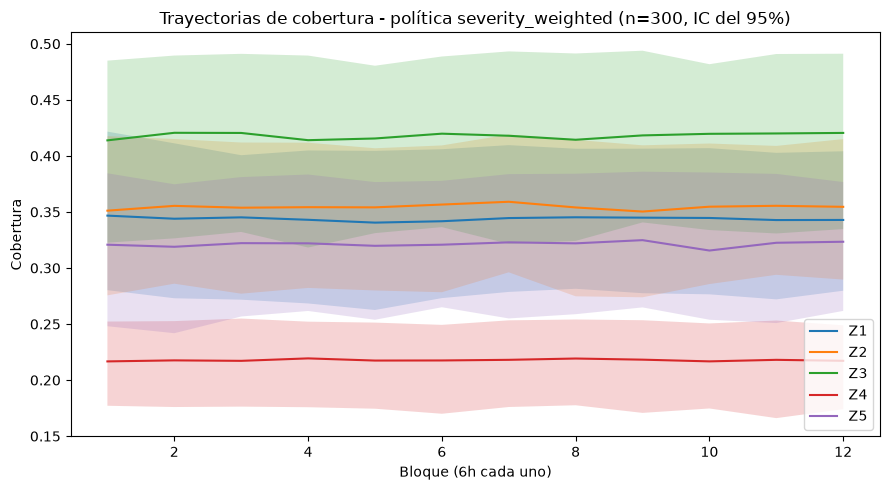

Resumen de métricas (severity_weighted, horizonte completo de 72h):
  M1_tasa_mortalidad_evitable: media=6.985  IC 95%=[6.802, 7.160]
  M2_tiempo_promedio_respuesta: media=1.570  IC 95%=[0.000, 7.575]
  M3_cobertura_suministros: media=29.308  IC 95%=[24.818, 33.322]
  M4_eficiencia_presupuestaria: media=693.632  IC 95%=[670.695, 714.593]
  weighted_policy_score: media=0.604  IC 95%=[0.406, 0.682]


In [15]:
mc_baseline_full = run_replications(params, POLICIES["severity_weighted"], n=N_REPLICATIONS, seed=DEFAULT_SEED)

coverage_mean, coverage_lo, coverage_hi = summarize(mc_baseline_full["coverage_traj"], axis=0)
fig = plot_trajectories(
    coverage_mean, coverage_lo, coverage_hi,
    title=f"Trayectorias de cobertura - política severity_weighted (n={N_REPLICATIONS}, IC del 95%)",
    savepath=OUTPUTS / "coverage_trajectories_baseline.png",
)
plt.show()

print("Resumen de métricas (severity_weighted, horizonte completo de 72h):")
for name, arr in mc_baseline_full["metrics"].items():
    m, lo, hi = summarize(arr)
    print(f"  {name}: media={m:.3f}  IC 95%=[{lo:.3f}, {hi:.3f}]")


## 5. Resultados: Pregunta 1 (análisis propio, antes del intercambio)

"Con base únicamente en los datos de su archivo y antes de incorporar la información del intercambio, proponga una asignación inicial de recursos para las primeras 24 horas. Evalúe esa asignación contra las cuatro métricas de política definidas en su archivo. Cuál métrica es la más difícil de cumplir con los recursos disponibles y por qué?"

Comparamos las 6 políticas de la Sección 4.2 restringidas a las primeras 24 horas (bloques 1-4, `n_blocks=4`), evaluamos las cuatro métricas para cada una, y además demostramos `manual_plan` con una tabla de ejemplo codificada a mano (reemplazar con la propuesta real del grupo).


In [16]:
CANDIDATE_POLICIES = [
    "equal_share", "proportional_to_need", "severity_weighted",
    "worst_first", "threshold_then_proportional", "score_prioridad",
]

q1_mc = {}
for name in CANDIDATE_POLICIES:
    q1_mc[name] = run_replications(
        params, POLICIES[name], n=N_REPLICATIONS, seed=DEFAULT_SEED, n_blocks=4
    )

# Ejemplo de propuesta manual de 24h codificada a mano (reemplazar con la
# propuesta real del grupo una vez finalizada); ilustrada para un recurso, kits_agua.
manual_table_example = np.tile(np.array([100.0, 40.0, 70.0, 20.0, 110.0]), (4, 1))
manual_policy_example = manual_plan(manual_table_example)
q1_mc["manual_plan_example"] = run_replications(
    params, manual_policy_example, n=N_REPLICATIONS, seed=DEFAULT_SEED, n_blocks=4
)

q1_rows = []
for policy_name, mc in q1_mc.items():
    row = {"policy": policy_name}
    for metric_name, arr in mc["metrics"].items():
        mean, lo, hi = summarize(arr)
        row[f"{metric_name}_mean"] = mean
        row[f"{metric_name}_ci"] = f"[{lo:.2f}, {hi:.2f}]"
    q1_rows.append(row)

q1_table = pd.DataFrame(q1_rows).set_index("policy")
q1_table


,M1_tasa_mortalidad_evitable_mean,M1_tasa_mortalidad_evitable_ci,M2_tiempo_promedio_respuesta_mean,M2_tiempo_promedio_respuesta_ci,M3_cobertura_suministros_mean,M3_cobertura_suministros_ci,M4_eficiencia_presupuestaria_mean,M4_eficiencia_presupuestaria_ci,weighted_policy_score_mean,weighted_policy_score_ci
policy,,,,,,,,,,
equal_share,2.364703,"[2.31, 2.42]",78.00,"[78.00, 78.00]",29.479098,"[25.55, 32.40]",1976.522195,"[1900.57, 2061.03]",0.544828,"[0.53, 0.55]"
proportional_to_need,1.989895,"[1.91, 2.07]",3.68,"[0.00, 39.00]",29.311911,"[24.53, 33.14]",2073.831427,"[1965.43, 2182.59]",0.703885,"[0.54, 0.81]"
severity_weighted,1.936280,"[1.84, 2.02]",1.75,"[0.00, 7.57]",29.308137,"[24.82, 33.32]",2080.820748,"[1967.39, 2199.38]",0.742029,"[0.54, 0.82]"
worst_first,2.155641,"[2.08, 2.22]",26.24,"[6.00, 78.00]",30.000264,"[25.46, 33.65]",2063.336295,"[1968.52, 2165.31]",0.550638,"[0.54, 0.56]"
threshold_then_proportional,2.060897,"[1.99, 2.13]",27.41,"[0.00, 78.00]",30.511016,"[25.42, 34.27]",2137.413381,"[2033.71, 2239.38]",0.589546,"[0.54, 0.81]"
score_prioridad,1.999376,"[1.91, 2.08]",11.69,"[0.00, 42.00]",30.304804,"[25.68, 34.12]",2132.688830,"[2022.75, 2245.49]",0.640132,"[0.54, 0.81]"
manual_plan_example,2.635911,"[2.57, 2.70]",78.00,"[78.00, 78.00]",30.789524,"[26.07, 34.61]",39795.208236,"[37231.01, 42523.42]",0.543499,"[0.53, 0.56]"


### Nota de referencia (hallazgo calculado por el modelo, no reemplaza el razonamiento del equipo)

Según la calibración de referencia (`q1_table` de arriba), `M3_cobertura_suministros` suele ser la más difícil de cumplir en todas las políticas, porque el stock de kits de agua (2,800 kits en total) es una dotación fija de T0 pequeña en relación con la población en riesgo (84,900): incluso una política perfectamente focalizada no puede alcanzar el umbral del 80% en 24h dada esa escasez. Con la corrección de M2 (Sección 4.6), `M2_tiempo_promedio_respuesta` también queda muy por encima de su umbral de 6h para la mayoría de las políticas (ver `q1_table`), por lo que el equipo debe comparar ambas métricas contra su umbral antes de concluir cuál es realmente "la más difícil". Este hallazgo de referencia debe revalidarse una vez que las tasas reales de necesidad per capita reemplacen a las etiquetadas `# ASSUMPTION:` en la Sección 4.1.

### Respuesta a Pregunta 1 - `[PENDIENTE - equipo]`

Con los resultados de `q1_table`, identificar cuál de las 4 métricas queda más lejos de su umbral aceptable (comparar `media` / IC contra `umbral`, Sección 4.6) y explicar por qué, en términos del cuello de botella real del sistema (revisar `params.resource_available_t0` vs. `params.population_at_risk` para el argumento cuantitativo). La nota de referencia de arriba es un punto de partida calculado por el modelo, no el razonamiento final que debe entregar el equipo.


## 6. Intercambio presencial: información recibida de los Grupos 2, 3 y 5

El Grupo 7 RECIBE tres reportes en el intercambio presencial (ver Sección 4.3 para los esquemas y cargadores ya implementados):

- Grupo 2: reporte de saturación hospitalaria + recursos críticos faltantes.
- Grupo 3: balance de suministros: déficit por zona y momento de agotamiento del stock.
- Grupo 5: plan de despliegue de personal + requerimientos de refuerzo.

Ninguno de estos existe todavía. Es necesario entregar las plantillas CSV de `data/exchange/README.md` a los Grupos 2, 3 y 5 durante el intercambio, para que sus reportes lleguen exactamente en la forma que este notebook espera. Completar la celda de abajo con notas informales de lo recibido en el intercambio (útil como registro human-readable, independiente de los CSV formales que carga `load_exchange_or_placeholder` en la Sección 7). Si los archivos reales aún no están disponibles, la Sección 7 usa como respaldo un pequeño intercambio sintético de referencia para que el flujo antes/después pueda ejecutarse desde ya.


In [17]:
# [PENDIENTE - equipo]: reemplazar estos placeholders con los datos reales entregados en el intercambio.
intercambio_grupo2 = {
    # "zona": {"pacientes_sin_atender": ..., "recursos_criticos_faltantes": [...]},
}

intercambio_grupo3 = {
    # "zona": {"suministro_deficitario": ..., "bloque_agotamiento": ...},
}

intercambio_grupo5 = {
    # "zona": {"bloque": ..., "refuerzos_requeridos": ...},
}


## 7. Resultados: Pregunta 2 (integración del intercambio)

"Incorpore los reportes recibidos de los Grupos 2, 3 y 5. Cambia su asignación inicial de recursos? Identifique la decisión que más cambió después del intercambio, justifique con los datos recibidos por qué cambió, y cuantifique el impacto de ese cambio sobre al menos dos de las cuatro métricas de evaluación."


In [18]:
exchange = load_exchange_or_placeholder()

q2_before = {}
q2_after = {}
for name in CANDIDATE_POLICIES:
    q2_before[name] = run_replications(
        params, POLICIES[name], n=N_REPLICATIONS, seed=DEFAULT_SEED, n_blocks=4, exchange=None
    )
    q2_after[name] = run_replications(
        params, POLICIES[name], n=N_REPLICATIONS, seed=DEFAULT_SEED, n_blocks=4, exchange=exchange
    )

# Enfocar la comparación antes/después en la política de trabajo seleccionada por el grupo.
SELECTED_POLICY = "severity_weighted"
q2_comparison_table = compare(q2_before[SELECTED_POLICY], q2_after[SELECTED_POLICY])
q2_comparison_table


No se encontraron los archivos reales de intercambio en data/exchange/. Se usa un pequeño intercambio SINTÉTICO DE REFERENCIA para que este notebook se ejecute de principio a fin desde ya. Reemplazar con los archivos reales después del intercambio presencial (ver data/exchange/README.md).


,metric,mean_before,ci_lo_before,ci_hi_before,mean_after,ci_lo_after,ci_hi_after,delta_mean,delta_ci_lo,delta_ci_hi
0,M1_tasa_mortalidad_evitable,1.936280,1.843739,2.022856,1.947074,1.853410,2.029789,0.010793,0.006159,0.014604
1,M2_tiempo_promedio_respuesta,1.750000,0.000000,7.575000,2.420000,0.000000,9.000000,0.670000,0.000000,6.000000
2,M3_cobertura_suministros,29.308137,24.818241,33.321906,28.345413,23.591440,32.141850,-0.962723,-1.539331,-0.142252
3,M4_eficiencia_presupuestaria,2080.820748,1967.391145,2199.381839,2066.559639,1953.103497,2182.612980,-14.261109,-19.457419,-7.706221
4,weighted_policy_score,0.742029,0.543228,0.815565,0.722138,0.538601,0.811957,-0.019891,-0.129342,-0.000589


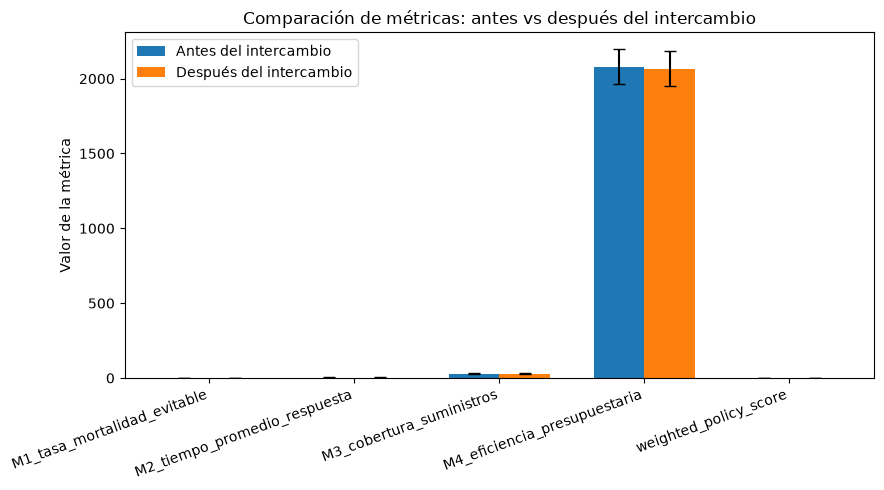

In [19]:
before_summary = {name: summarize(arr) for name, arr in q2_before[SELECTED_POLICY]["metrics"].items()}
after_summary = {name: summarize(arr) for name, arr in q2_after[SELECTED_POLICY]["metrics"].items()}

fig = plot_metric_comparison(before_summary, after_summary, savepath=OUTPUTS / "metric_comparison_q2.png")
plt.show()


### Respuesta a Pregunta 2 - `[PENDIENTE - equipo]`

Completar usando `q2_comparison_table` de arriba, por ejemplo: "el aumento de fondos médicos implicado por los déficits hospitalarios reportados por el Grupo 2 desplazó la asignación de `presupuesto_municipal` hacia Z1/Z5, cambiando `M1_tasa_mortalidad_evitable` en X puntos (IC 95% [.., ..]) y `M4_eficiencia_presupuestaria` en Y (IC 95% [.., ..])". Reemplazar X/Y con los valores impresos arriba una vez que los CSV reales del intercambio (Sección 6) reemplacen el placeholder sintético.


## 8. Análisis de sensibilidad (salida requerida d)

"Qué decisión cambia si el presupuesto nacional se reduce a la mitad (32M -> 16M)? Y si Z1 es inaccesible las primeras 12 horas (bloques 1-2)?"

Ambos escenarios se implementan como banderas en `Params` (`national_budget_multiplier`, `inaccessible_zone` / `inaccessible_blocks`) y se ejecutan a través del Monte Carlo completo, comparados contra la línea base.


In [20]:
baseline_sens_mc = run_replications(params, POLICIES[SELECTED_POLICY], n=N_REPLICATIONS, seed=DEFAULT_SEED)

halved_budget_params = replace(params, national_budget_multiplier=0.5)
halved_budget_mc = run_replications(halved_budget_params, POLICIES[SELECTED_POLICY], n=N_REPLICATIONS, seed=DEFAULT_SEED)

z1_inaccessible_params = replace(params, inaccessible_zone="Z1", inaccessible_blocks=(1, 2))
z1_inaccessible_mc = run_replications(z1_inaccessible_params, POLICIES[SELECTED_POLICY], n=N_REPLICATIONS, seed=DEFAULT_SEED)

sensitivity_budget_table = compare(baseline_sens_mc, halved_budget_mc)
sensitivity_z1_table = compare(baseline_sens_mc, z1_inaccessible_mc)

print("Escenario A: presupuesto nacional reducido a la mitad (32M -> 16M) vs. línea base")
display(sensitivity_budget_table)

print("Escenario B: Z1 inaccesible en los bloques 1-2 vs. línea base")
display(sensitivity_z1_table)


Escenario A: presupuesto nacional reducido a la mitad (32M -> 16M) vs. línea base


,metric,mean_before,ci_lo_before,ci_hi_before,mean_after,ci_lo_after,ci_hi_after,delta_mean,delta_ci_lo,delta_ci_hi
0,M1_tasa_mortalidad_evitable,6.985255,6.801867,7.160336,7.509100,7.326154,7.687468,0.523845,0.497597,0.550466
1,M2_tiempo_promedio_respuesta,1.570000,0.000000,7.575000,6.960000,0.000000,24.000000,5.390000,0.000000,24.000000
2,M3_cobertura_suministros,29.308137,24.818241,33.321906,29.308137,24.818241,33.321906,0.000000,0.000000,0.000000
3,M4_eficiencia_presupuestaria,693.632319,670.695388,714.592906,1017.329903,981.908331,1051.891186,323.697584,310.935453,337.251926
4,weighted_policy_score,0.604257,0.406349,0.682229,0.528073,0.427706,0.702792,-0.076185,-0.226399,0.030060


Escenario B: Z1 inaccesible en los bloques 1-2 vs. línea base


,metric,mean_before,ci_lo_before,ci_hi_before,mean_after,ci_lo_after,ci_hi_after,delta_mean,delta_ci_lo,delta_ci_hi
0,M1_tasa_mortalidad_evitable,6.985255,6.801867,7.160336,7.320891,7.140193,7.487083,0.335636,0.284359,0.377634
1,M2_tiempo_promedio_respuesta,1.570000,0.000000,7.575000,7.450000,6.000000,12.000000,5.880000,3.000000,9.000000
2,M3_cobertura_suministros,29.308137,24.818241,33.321906,24.478148,19.745484,27.936176,-4.829989,-6.484425,-2.838964
3,M4_eficiencia_presupuestaria,693.632319,670.695388,714.592906,654.658641,633.672946,674.676955,-38.973678,-44.338643,-32.504179
4,weighted_policy_score,0.604257,0.406349,0.682229,0.384114,0.365827,0.399911,-0.220143,-0.286514,-0.026313


Nota de calibración sobre los resultados de sensibilidad: bajo la calibración actual de referencia, reducir a la mitad el presupuesto nacional puede aumentar `M4_eficiencia_presupuestaria`. Esto no es un error: `presupuesto_nacional` domina el `budget_consumed` total (el denominador de M4) mucho más de lo que impulsa la métrica de cobertura agregada (el numerador de M4, promediado entre los 8 recursos), por lo que reducirlo baja el denominador más rápido que el numerador. Este es exactamente el tipo de comportamiento emergente, posiblemente no intencionado, que el equipo debería verificar una vez que se reemplacen las tasas reales de necesidad per capita (Sección 4.1, etiquetas `# ASSUMPTION:`), y merece una frase en la Sección 10 (Limitaciones) como ejemplo concreto de cómo un supuesto de referencia puede distorsionar la interpretación de una métrica.

### Lectura del análisis de sensibilidad - `[PENDIENTE - equipo]`

Comparar las columnas de `sensitivity_budget_table` y `sensitivity_z1_table` de arriba y explicar, para cada escenario, si cambia o no cambia el resultado respecto a la línea base, y por qué (pensar en cuál recurso es realmente la restricción activa del modelo: revisar `params.resource_available_t0`, `params.unit_cost` y el presupuesto total antes de concluir). La nota de calibración de arriba es una explicación técnica de un efecto observado en el modelo, no la lectura final que debe entregar el equipo sobre que decisión de política cambiaria.


## 9. Salida final requerida (a, b, c, d) y exportación

Según `docs/Grupo7_PoliticaPublica.xlsx`, sección "6. OUTPUT REQUERIDO - Producto final del examen", el Grupo 7 entrega directamente al profesor:

- (a) un plan de asignación de recursos a 72h por zona (los 12 bloques x 5   zonas x 8 recursos);
- (b) justificación cuantitativa de cada decisión de asignación usando los   reportes de los Grupos 2/3/5 (el registro de auditoría, C3);
- (c) evaluación del plan contra las 4 métricas con pass/fail e IC del 95%;
- (d) el análisis de sensibilidad de la Sección 8.

Las cuatro se exportan a `outputs/` a continuación.


(a) plan de asignación a 72h: (480, 7) -> outputs/a_allocation_plan_72h.csv
(b) registro de auditoría: (480, 7) -> outputs/b_audit_trail.csv
    violaciones de restricciones en esta realización: 1
(c) evaluación vs umbrales -> outputs/c_evaluation_vs_thresholds.csv


,metric,label,mean,ci_lo,ci_hi,threshold,weight,pass
0,M1_tasa_mortalidad_evitable,Tasa de mortalidad evitable,6.985255,6.801867,7.160336,15.0,0.30,True
1,M2_tiempo_promedio_respuesta,"Tiempo promedio de respuesta (horas, zonas CRI...",1.570000,0.000000,7.575000,6.0,0.25,True
2,M3_cobertura_suministros,Cobertura de suministros en 24h (%),29.308137,24.818241,33.321906,80.0,0.25,False
3,M4_eficiencia_presupuestaria,Eficiencia presupuestaria (personas/MQ),693.632319,670.695388,714.592906,850.0,0.20,False


(d) tablas de sensibilidad -> outputs/d_sensitivity_*.csv


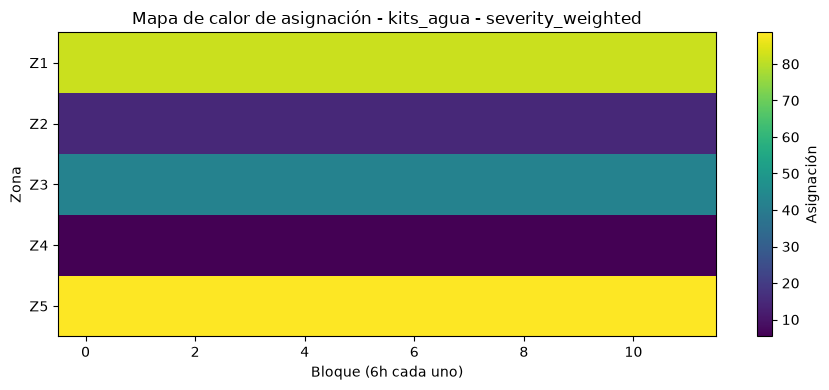


Todas las salidas fueron exportadas a: /home/jonialen/Documents/uvg/s8/mod/examenP1/outputs
 - .gitkeep
 - a_allocation_plan_72h.csv
 - allocation_heatmap_kits_agua.png
 - b_audit_trail.csv
 - c_evaluation_vs_thresholds.csv
 - coverage_trajectories_baseline.png
 - d_sensitivity_national_budget_halved.csv
 - d_sensitivity_z1_inaccessible.csv
 - metric_comparison_q2.png
 - q1_policy_comparison.csv
 - q2_before_after_comparison.csv


In [21]:
# (a) Plan de asignación a 72h: una corrida deterministica de la política
# seleccionada sobre el horizonte completo, exportada como tabla en formato largo.
rng_final = np.random.default_rng(DEFAULT_SEED)
final_result = simulate(params, POLICIES[SELECTED_POLICY], rng_final, exchange=exchange)

plan_rows = []
for t in range(final_result.n_blocks):
    for z_idx, z in enumerate(ZONES):
        for r_idx, r in enumerate(RESOURCE_TYPES):
            plan_rows.append({
                "block": t + 1,
                "hour_start": block_to_hours(t + 1)[0],
                "hour_end": block_to_hours(t + 1)[1],
                "zone": z,
                "resource": r,
                "units_allocated": round(float(final_result.allocation[t, z_idx, r_idx]), 2),
                "units_delivered": round(float(final_result.delivered[t, z_idx, r_idx]), 2),
            })
allocation_plan_72h = pd.DataFrame(plan_rows)
allocation_plan_72h.to_csv(OUTPUTS / "a_allocation_plan_72h.csv", index=False)
print("(a) plan de asignación a 72h:", allocation_plan_72h.shape, "-> outputs/a_allocation_plan_72h.csv")

# (b) Registro de auditoría (C3, justificación cuantitativa de cada decisión).
final_audit_trail = build_audit_trail(final_result, params, SELECTED_POLICY)
final_audit_trail.to_csv(OUTPUTS / "b_audit_trail.csv", index=False)
print("(b) registro de auditoría:", final_audit_trail.shape, "-> outputs/b_audit_trail.csv")

final_violations = check_constraints(final_result, params)
print(f"    violaciones de restricciones en esta realización: {len(final_violations)}")

# (c) Evaluación contra las 4 métricas, con pass/fail e IC del 95% (a partir
# de la corrida de Monte Carlo ya calculada para la política seleccionada en la Sección 4.9/8).
eval_rows = []
for name in METRICS:
    mean, lo, hi = summarize(baseline_sens_mc["metrics"][name])
    d = METRIC_DEFS[name]
    passed = (mean < d["threshold"]) if d["direction"] == "lower_is_better" else (mean > d["threshold"])
    eval_rows.append({
        "metric": name, "label": d["label"], "mean": mean, "ci_lo": lo, "ci_hi": hi,
        "threshold": d["threshold"], "weight": d["weight"], "pass": passed,
    })
evaluation_table = pd.DataFrame(eval_rows)
evaluation_table.to_csv(OUTPUTS / "c_evaluation_vs_thresholds.csv", index=False)
print("(c) evaluación vs umbrales -> outputs/c_evaluation_vs_thresholds.csv")
display(evaluation_table)

# (d) Tablas del análisis de sensibilidad (Sección 8).
sensitivity_budget_table.to_csv(OUTPUTS / "d_sensitivity_national_budget_halved.csv", index=False)
sensitivity_z1_table.to_csv(OUTPUTS / "d_sensitivity_z1_inaccessible.csv", index=False)
print("(d) tablas de sensibilidad -> outputs/d_sensitivity_*.csv")

# También exportar las tablas de Q1/Q2 y las figuras clave.
q1_table.to_csv(OUTPUTS / "q1_policy_comparison.csv")
q2_comparison_table.to_csv(OUTPUTS / "q2_before_after_comparison.csv", index=False)

fig = plot_allocation_heatmap(
    final_result.allocation[:, :, RESOURCE_TYPES.index("kits_agua")],
    title=f"Mapa de calor de asignación - kits_agua - {SELECTED_POLICY}",
    savepath=OUTPUTS / "allocation_heatmap_kits_agua.png",
)
plt.show()

print()
print("Todas las salidas fueron exportadas a:", OUTPUTS)
for p in sorted(OUTPUTS.iterdir()):
    print(" -", p.name)


## 10. Limitaciones y propuestas de mejora

### Puntos de partida ya identificados durante el desarrollo (revisar antes de usar)

- Las tasas de necesidad per capita (`Params.baseline_need_per_capita`,   Sección 4.1) son supuestos calibrados, no datos del archivo Excel; con   más tiempo se solicitarían al comité de emergencia tasas reales por tipo   de recurso.
- La restricción C4 (coordinación para vehículos pesados) se modela con una   probabilidad de disponibilidad de ruta inventada   (`route_availability_probability`) porque el Grupo 7 no recibe   directamente el mapa de accesibilidad del Grupo 4; con más datos, esta   probabilidad deberia derivarse del índice de aislamiento real de esa   zona.
- La métrica M4 (eficiencia presupuestaria) puede mostrar comportamiento   contraintuitivo bajo la calibración actual (ver la nota de la Sección 8:   reducir el presupuesto nacional a la mitad puede aumentar la eficiencia   calculada) porque el presupuesto nacional domina el gasto total mucho más   de lo que impulsa la cobertura agregada; esto es una limitación de   calibración, no del diseño del modelo, y debe corregirse cuando se   reemplacen los supuestos por datos reales.
- La métrica M2 (tiempo promedio de respuesta) tenía un defecto de diseño   que se corrigió en la Sección 4.6 (medía la primera entrega mayor a cero   en vez de una cobertura mínima significativa); el umbral   `MIN_COVERAGE_FOR_RESPONSE = 0.30` sigue siendo un supuesto calibrado   empiricamente, no un dato del Excel, y deberia revisarse con criterio de   dominio (por ejemplo, que fracción de cobertura corresponde realmente a   "la zona ya fue atendida" en una emergencia real).

### Limitaciones y propuestas de mejora - `[PENDIENTE - equipo]`

Identificar al menos dos limitaciones estructurales del modelo (no de implementación menor) y proponer cómo se resolverían con más tiempo o datos. Los puntos de arriba son un punto de partida ya identificado durante el desarrollo del modelo, revisarlos antes de copiarlos: el equipo debe argumentar cuáles son realmente las limitaciones más importantes y por qué, no solo repetir la lista.


## 11. Documentación de uso de IA generativa (requisito del examen)

"Si necesitan usarla, asegúrense de colocar el prompt que utilizan para cada task donde corresponda, así como una explicación de por qué ese prompt funcionó."

El registro completo de prompts de IA generativa vive únicamente en `docs/prompts_ia.md` (una fila por tarea, con el prompt usado, por qué funcionó, y qué se tuvo que ajustar). Esta sección del notebook no duplica esa tabla: apunta a ella para evitar tener dos fuentes de verdad desincronizadas.

`[PENDIENTE - equipo]` Completar `docs/prompts_ia.md` con cada prompt real que se usó durante el desarrollo de este notebook y del reporte, y por qué funcionó o qué se tuvo que ajustar. Recordar: toda decisión de diseño debe estar justificada con los criterios vistos en clase; una justificación que solo repite texto generado por IA sin razonamiento propio no obtiene puntaje en ese criterio.
